In [1]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('tables/units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  firing_rate  response_mag  sparsity  pyr  sst  ...  \
0           0           0     2.347611     -0.165334 -0.110431    1    0  ...   
1           0           0     0.608558     -0.119121 -0.137173    1    0  ...   
2           0           0     0.932567      0.146078  0.053006    1    0  ...   
3           0           4    11.398961     -0.184356 -0.109291    1    0  ...   
4           0           0     8.338130      0.441873 -0.053603    0    0  ...   

   burstIndex_Royer2012  burstIndex_Mizuseki2012  num_co

### define session and hyperparameters

In [ ]:
# Session obj contains stimulus, channel, and unit information
output_dir  = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022')
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
input_size = len(session_obj.units)
num_epochs = 15 # 
batch_size = 32

# hyperparameters
hidden_size = 50 # 
num_layers = 1
seqlength = 750

# define output directory for saved models
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
output_dir_plots = output_dir_models / 'plots'
os.makedirs(output_dir_models, exist_ok=True)
os.makedirs(output_dir_plots, exist_ok=True)


### get spikes and LFP for active data

In [198]:
# Spikes obj contains Spike matrix
bin_size=0.004
sr = 1/bin_size
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
# spikes_obj.convolve_with_gaussian() # skip convolution
spikes_obj.minmax()

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(int(1250 /sr)) # Downsample by 5
lfp_obj.truncate(seqlength)
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

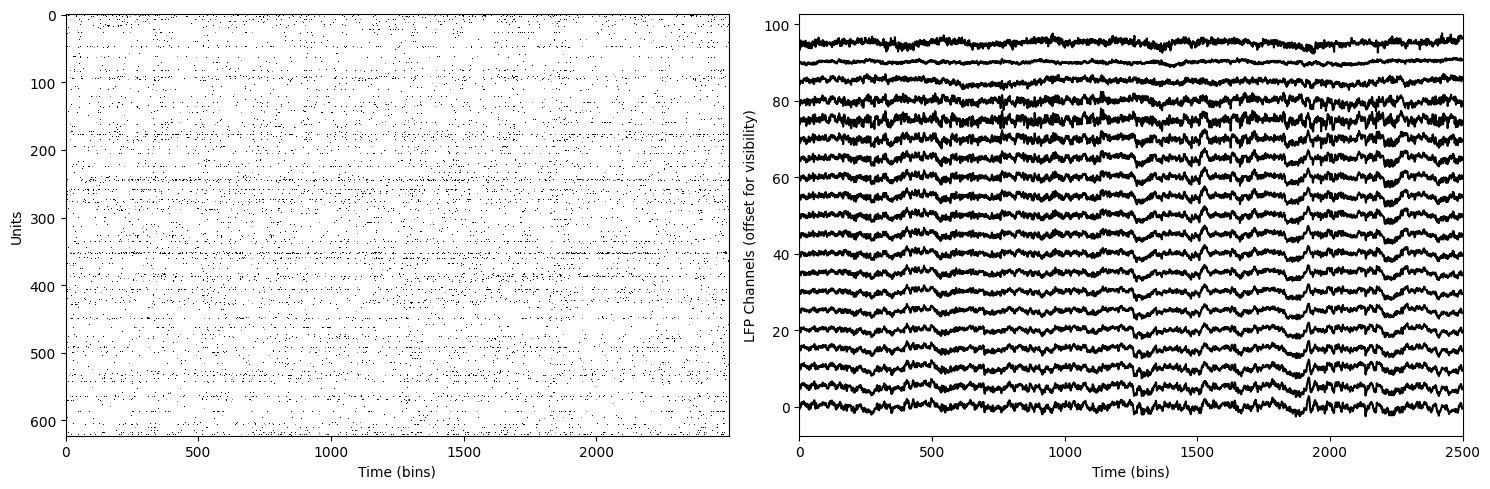

In [236]:
# visualize the first 20 seconds of spikes using a heatmap

fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].imshow(spikes_obj.spkMat[:10 * int(sr), :].T * -1 , aspect='auto', cmap='gray', interpolation='none')
# ax[0].colorbar(label='Normalized Spike Rate')
ax[0].set_xlabel('Time (bins)')
ax[0].set_ylabel('Units')

# in the second subplot, plot the broadband LFPs from all channels with a vertical offset
offset = 5
for i in range(num_channels):
    ax[1].plot(lfp_obj.lfpMat[:10 * int(sr), i, 0] + i * offset, color='black')
ax[1].set_xlabel('Time (bins)')
ax[1].set_ylabel('LFP Channels (offset for visibility)')
ax[1].set_xlim(0, 10 * int(sr))
plt.tight_layout()
plt.savefig(Path(output_dir_plots) / 'spikes_lfp_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### get spikes and LFP for spontaneous and passive data

In [58]:
# get spontaneous data
spikes_obj_spont = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_spont.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj_spont.truncate(seqlength)
# spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.minmax()

lfp_obj_spont = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.spontaneous_times[0],
                              session_obj.spontaneous_times[1], output_dir) 
lfp_obj_spont.filter_lfp(take_power = True)
lfp_obj_spont.downsample_lfp(int(1250 /sr)) # Downsample by 5
lfp_obj_spont.truncate(seqlength) # Downsample by 5
lfp_obj_spont.align_lfp(spikes_obj_spont.spkMat.shape[0])

# # get passive data
# spikes_obj_passive = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
# spikes_obj_passive.getSpkMat(session_obj.passive_times[0], session_obj.passive_times[1])
# spikes_obj_passive.truncate(seqlength)
# spikes_obj_passive.convolve_with_gaussian()
# spikes_obj_passive.zscore()

# lfp_obj_passive = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.passive_times[0],
#                                 session_obj.passive_times[1], output_dir)
# lfp_obj_passive.filter_lfp()
# lfp_obj_passive.downsample_lfp(5) # Downsample by 5
# lfp_obj_passive.truncate(seqlength) # Downsample by 5
# lfp_obj_passive.align_lfp(spikes_obj_passive.spkMat.shape[0])

### compare models on broadband activity from one channel 

In [59]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)

test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

In [61]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.7517
Linear regression test loss: 0.7509


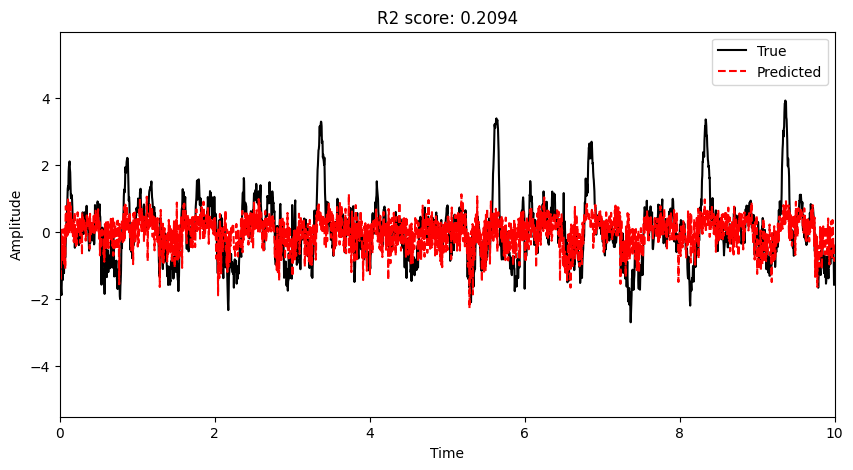

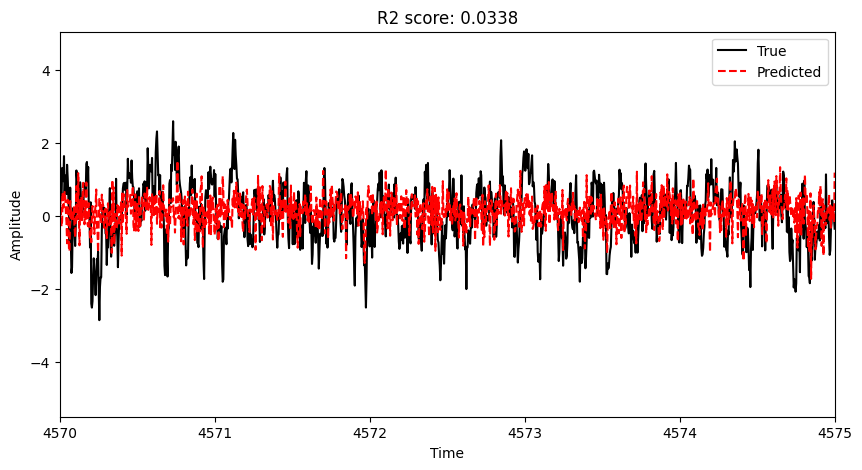

In [67]:
# 3. Evaluate the linear model
y_hat_test = linear_model.evaluate(test_spikes)

time_test = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_test, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time_test, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()

# save figure in pdf format
plt.savefig(output_dir_plots / 'linear_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()


y_hat_spont = linear_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()

# save figure in pdf format
plt.savefig(output_dir_plots / 'linear_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

In [68]:
# GRU model
gru_model = models.process_model(models.GRUnet(input_size, hidden_size, num_layers,seqlength, batchNorm=False), criterion, device)
gru_train_loss, gru_test_loss = gru_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

total_params = sum(p.numel() for p in gru_model.model.parameters())
print(f"Total parameters: {total_params:,}")
print(f'GRU  train loss: {gru_train_loss[-1]:.4f}')
print(f'GRU  test loss: {gru_test_loss[-1]:.4f}')

Total parameters: 102,547
GRU  train loss: 0.1361
GRU  test loss: 0.1345


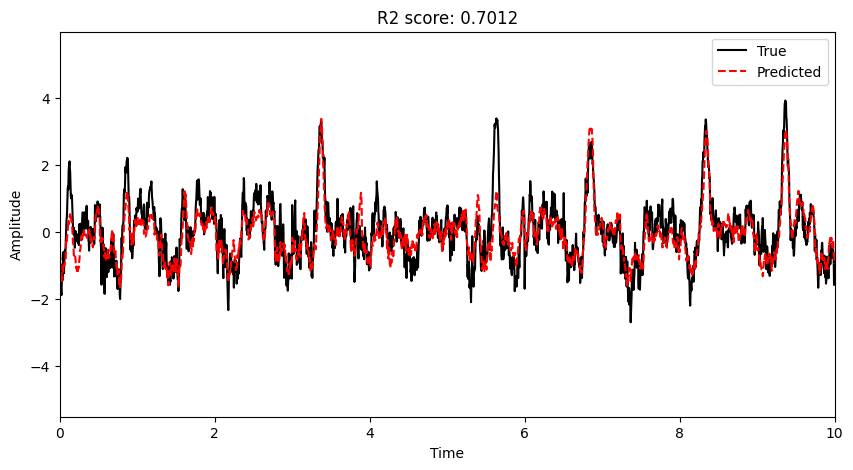

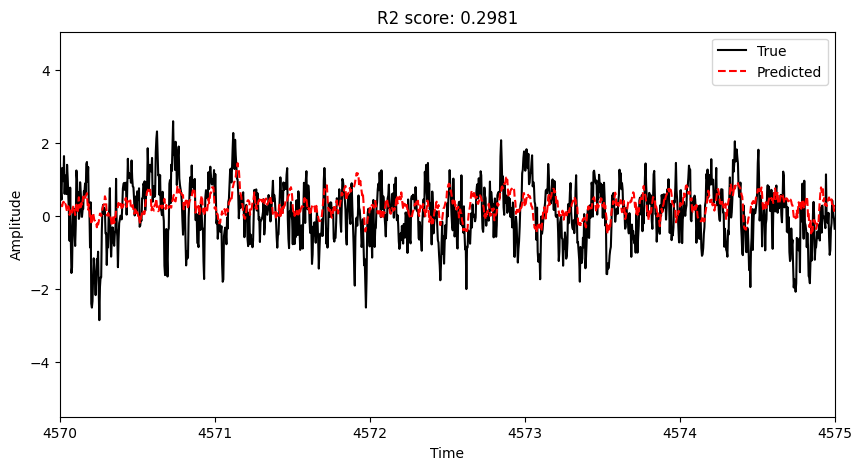

In [69]:
y_hat_test = gru_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'GRU_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

y_hat_spont = gru_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'GRU_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [70]:
# LSTM model
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

total_params = sum(p.numel() for p in lstm_model.model.parameters())
print(f"Total parameters: {total_params:,}")
print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

Total parameters: 116,627
LSTM  train loss: 0.1155
LSTM  test loss: 0.1187


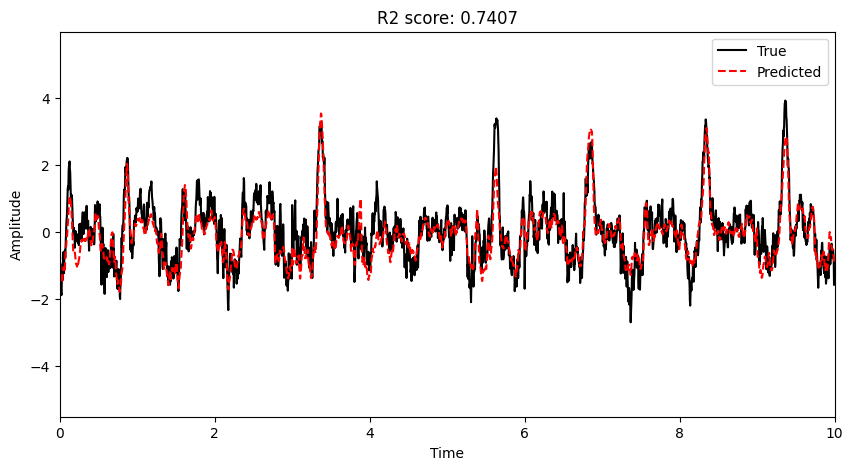

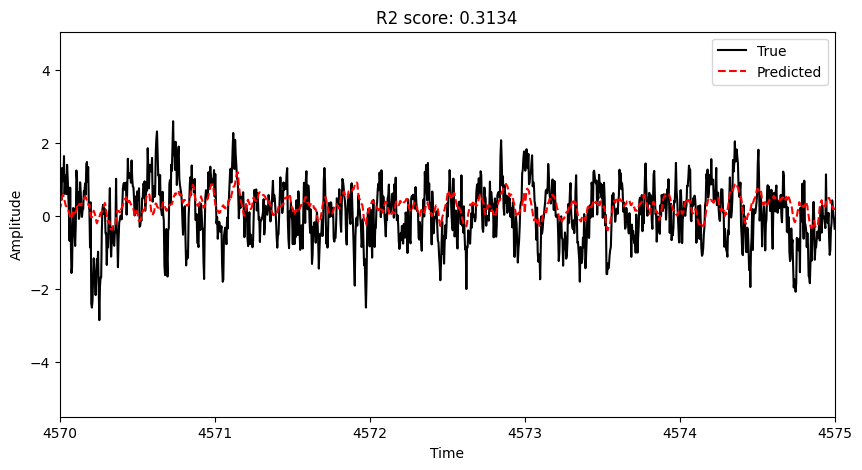

In [71]:
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'LSTM_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'LSTM_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show() 

In [72]:
# transformer model
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=50,
                                                                   embedding_dim = 32,
                                                                   num_heads = 2, 
                                                                   num_layers = 2, use_conv=True, conv_kernel_size=3,
                                                                   conv_out_channels=64,
                                                                   dropout=0.1), criterion, device)

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                    50, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer, lr = 0.0004, weight_decay= 6.7e-06)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.1229
transformer  test loss:  0.1267


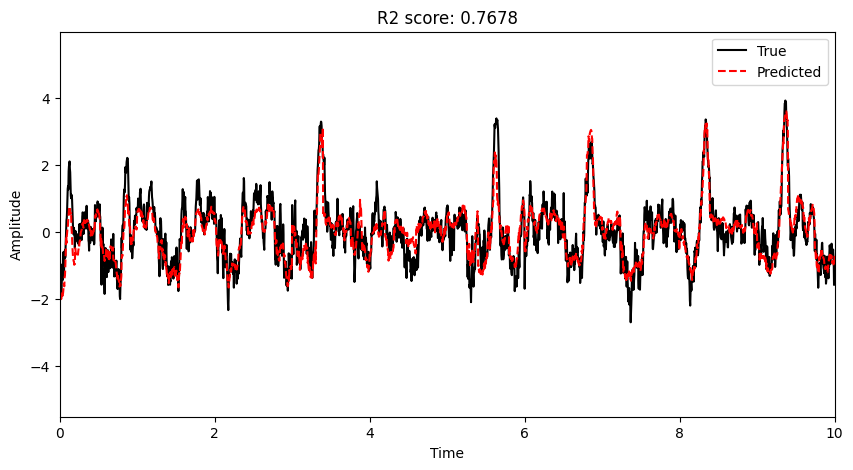

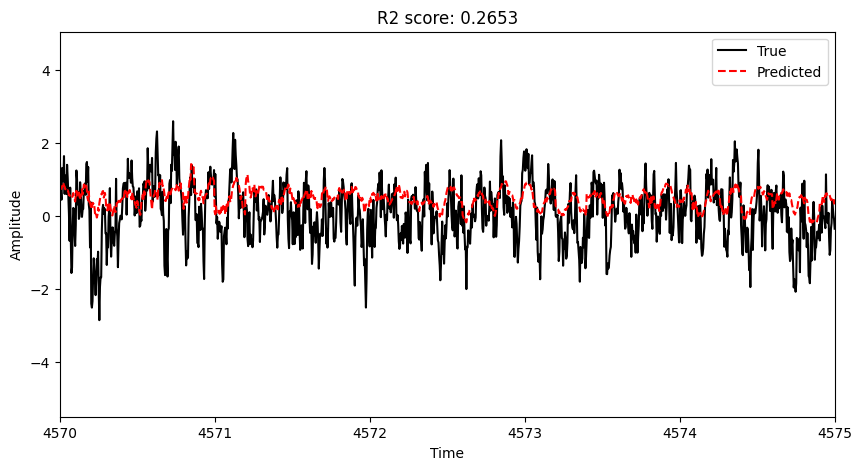

In [73]:
y_hat_test = transformer_model.evaluate(test_spikes)

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format 
plt.savefig(output_dir_plots / 'Transformer_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

y_hat_spont = transformer_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format 
plt.savefig(output_dir_plots / 'Transformer_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

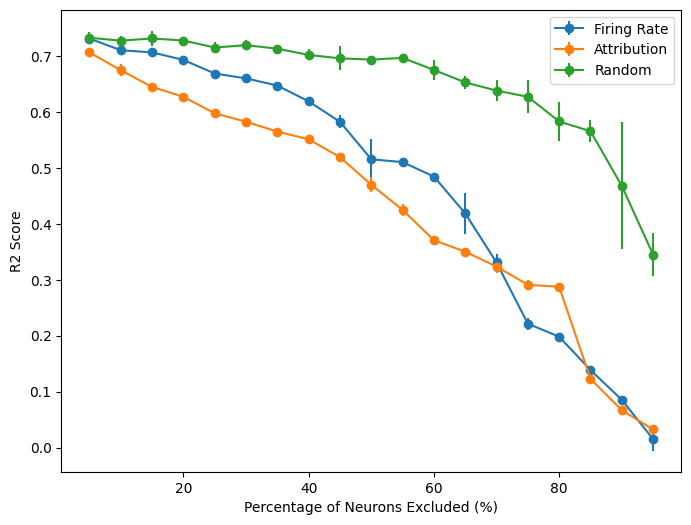

In [57]:
# plot with error bars
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.errorbar(steps, R2_fr.mean(axis=1), yerr=R2_fr.std(axis=1), fmt='-o', label='Firing Rate')
ax.errorbar(steps, R2_attr.mean(axis=1), yerr=R2_attr.std(axis=1), fmt='-o', label='Attribution')
ax.errorbar(steps, R2_rand.mean(axis=1), yerr=R2_rand.std(axis=1), fmt='-o', label='Random')
ax.set_xlabel('Percentage of Neurons Excluded (%)')
ax.set_ylabel('R2 Score')
plt.legend()
plt.show()

### investigate the hidden states of the LSTM model

In [112]:
# Initialize hidden state
h = torch.zeros(num_layers, 1, hidden_size).to(device)
c = torch.zeros(num_layers, 1, hidden_size).to(device)

hidden_states = []
cell_states = []

with torch.no_grad():
    for i in range(test_spikes.shape[0]):
        x = test_spikes[i].unsqueeze(0).unsqueeze(0).to(device)
        output, (h, c) = lstm_model.model.lstm(x, (h, c))
        hidden_states.append(h.squeeze(0).cpu().numpy())
        cell_states.append(c.squeeze(0).cpu().numpy())
        
hidden_states = np.array(hidden_states)
cell_states = np.array(cell_states)

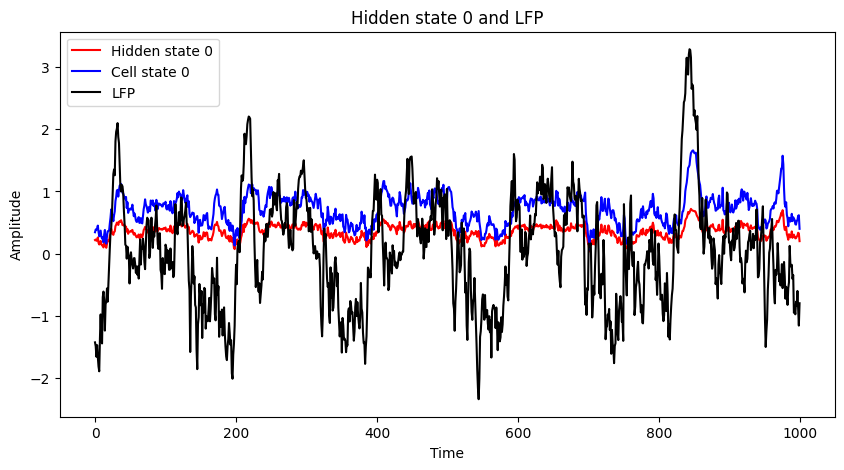

In [160]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(hidden_states[:1000,0, 0], 'r', label='Hidden state 0')
ax.plot(cell_states[:1000,0, 0], 'b', label='Cell state 0')
ax.plot(test_lfp[:1000].cpu().numpy(), 'k', label='LFP')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('Hidden state 0 and LFP')
plt.legend()
plt.show()

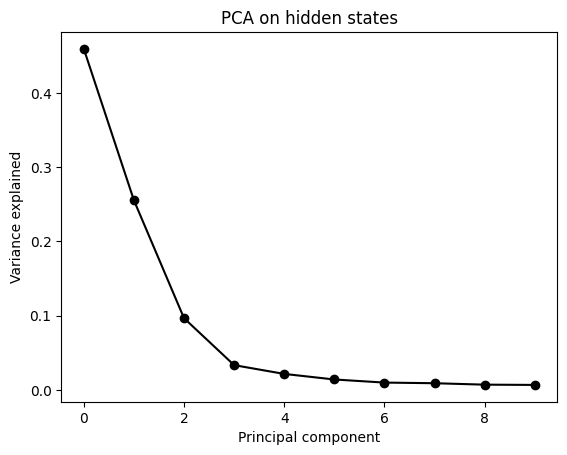

In [149]:
# do pca on hidden and cell states
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
pca.fit(hidden_states.reshape(-1, hidden_states.shape[-1]))
pca_hidden = pca.transform(hidden_states.reshape(-1, hidden_states.shape[-1]))

plt.plot(pca.explained_variance_ratio_, 'ko-')
plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.title('PCA on hidden states')
plt.show()

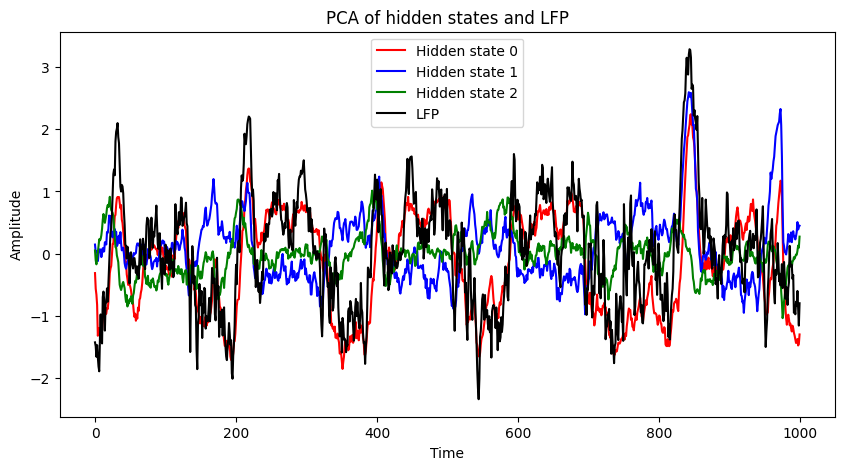

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(pca_hidden[:1000,0], 'r', label='Hidden state 0')
ax.plot(pca_hidden[:1000,1], 'b', label='Hidden state 1')
ax.plot(pca_hidden[:1000,2], 'g', label='Hidden state 2')
ax.plot(test_lfp[:1000].cpu().numpy(), 'k', label='LFP')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('PCA of hidden states and LFP')
plt.legend()
plt.show()

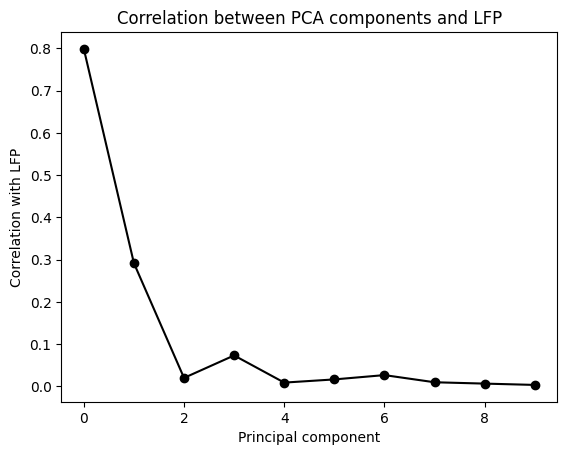

In [164]:
# plot the correlation between the PCA components and the LFP
from scipy.stats import pearsonr

lfp_hidden_corr = []
for i in range(pca_hidden.shape[1]):
    corr, _ = pearsonr(pca_hidden[:,i], test_lfp.cpu().numpy())
    lfp_hidden_corr.append(corr)

lfp_hidden_corr = np.array(lfp_hidden_corr)    
plt.plot(np.abs(lfp_hidden_corr), 'ko-')
plt.xlabel('Principal component')
plt.ylabel('Correlation with LFP')
plt.title('Correlation between PCA components and LFP')
plt.show()

### run the LSTM model on all channels and bands

In [6]:
lossesTrain, lossesTest = (np.zeros((len(lfp_obj.channels), num_epochs, len(bands)+1)) for _ in range(2))
R2_train, R2_test       = (np.zeros((len(lfp_obj.channels), len(bands)+1)) for _ in range(2))

# initialize dictionary to store trained models 
all_models = {}

for bandi in range(len(bands)+1):
    sys.stdout.write('\r' + 'Working on band ' + str(bandi + 1) + ' out of ' + str(len(bands)+1) + '\n')
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,:,bandi], 
                                                      seqlength, test_size=0.2, random_state=42)

    for chani in range(len(lfp_obj.channels)):
        sys.stdout.write('\t' + 'Training model for channel ' + str(chani+1) + ' out of ' + str(lfp_obj.lfpMat.shape[1]) + '\n')
        
        train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train[:,:,chani], y_test[:,:,chani], batch_size)
        
        model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
        
        train_loss, test_loss = model.train(train_dataloader,
                                        test_dataloader , num_epochs)
        
        yHat = model.evaluate(test_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_test[chani, bandi] = r2_score(test_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        yHat = model.evaluate(train_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_train[chani, bandi] = r2_score(train_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        
        lossesTrain[chani,:, bandi] = train_loss
        lossesTest[chani,:, bandi] = test_loss
        
        all_models[chani, bandi] = model


Working on band 1 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model for channel 4 out of 20
	Training model for channel 5 out of 20
	Training model for channel 6 out of 20
	Training model for channel 7 out of 20
	Training model for channel 8 out of 20
	Training model for channel 9 out of 20
	Training model for channel 10 out of 20
	Training model for channel 11 out of 20
	Training model for channel 12 out of 20
	Training model for channel 13 out of 20
	Training model for channel 14 out of 20
	Training model for channel 15 out of 20
	Training model for channel 16 out of 20
	Training model for channel 17 out of 20
	Training model for channel 18 out of 20
	Training model for channel 19 out of 20
	Training model for channel 20 out of 20
Working on band 2 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model

In [82]:
# get model predictions for the entire active session
yHat_active = np.zeros((lfp_obj.lfpMat.shape[0], lfp_obj.lfpMat.shape[1], len(bands)+1))
for chani in range(len(lfp_obj.channels)):
    for bandi in range(len(bands)+1):
        prediction = all_models[chani, bandi].evaluate(torch.tensor(spikes_obj.spkMat).float().to(device))
        yHat_active[:,chani,bandi] = prediction.cpu().detach().numpy()

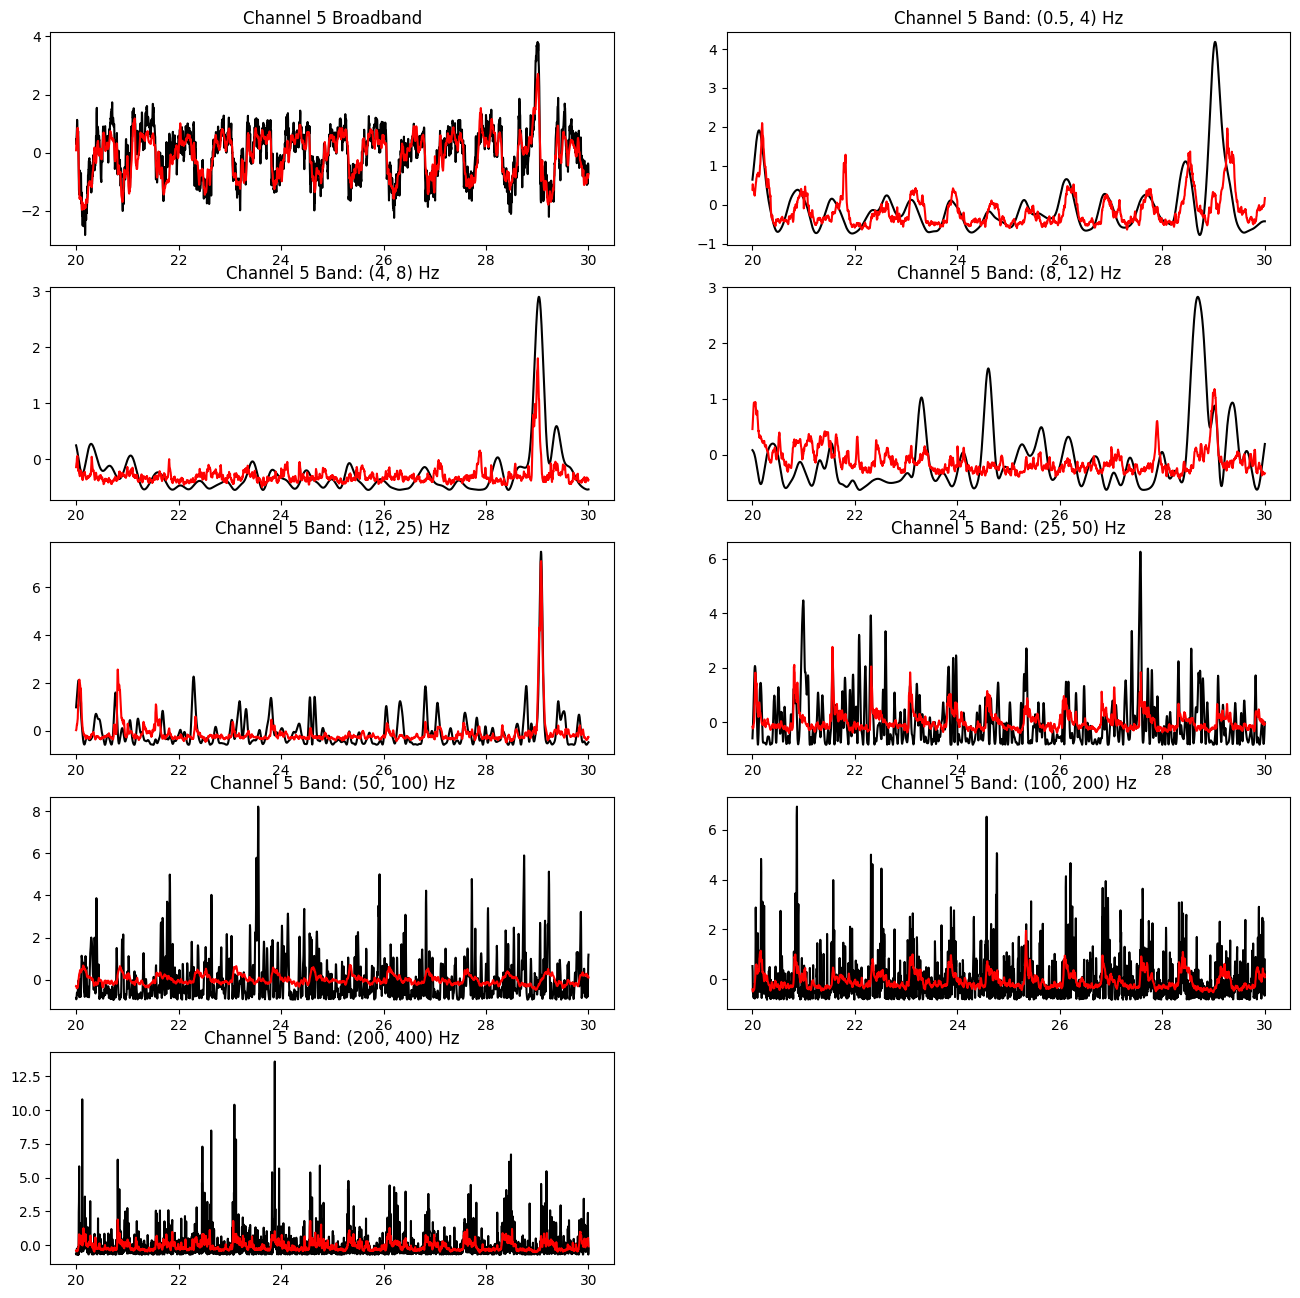

In [ ]:
plot_r2(R2_test, lfp_obj.channels, bands)
plot_all_channel_loss(lfp_obj.channels, bands, 0, lossesTest)
plot_lfp_prediction(lfp_obj.lfpMat, yHat_active, 5, bands, start_time = 20, end_time = 30, save_fig=True, output_dir=output_dir_plots)
plot_abs_error_change(lfp_obj.lfpMat, yHat_active, session_obj, spikes_obj.timestamps, 5, bands)
plot_psd(lfp_obj.lfpMat, yHat_active, 5)

In [ ]:
# save the models 
for idx in range(len(all_models.keys())):
    chan = list(all_models.keys())[idx][0]
    band = list(all_models.keys())[idx][1]
    filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
    torch.save(all_models[chan, band].model.state_dict(), filename)

In [78]:
# load the models if not in memory
if 'all_models' not in locals():
    all_models = {}
    for chan in range(num_channels):
        for band in range(len(bands)+1):
            filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
            model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
            model.model.load_state_dict(torch.load(filename))
            all_models[chan, band] = model
print('Models loaded from disk')

Models loaded from disk


In [ ]:
os.makedirs(output_dir_models / 'attrs' , exist_ok=True)
from IntegratedGradient import IntegratedGradient
import tqdm

attr_dur = 720
X_attr = torch.tensor(spikes_obj.spkMat[:int(attr_dur/bin_size),:]).float().to(device)
num_trials = int(int(attr_dur/bin_size)/seqlength)
X_attr = X_attr.reshape(num_trials, seqlength, X_attr.shape[1])
mean_attribution = np.zeros((num_channels, len(bands)+1 , spikes_obj.spkMat.shape[1]))

for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        model = all_models[chani, bandi]
        ig = IntegratedGradient(model.model.train().to(device), method='last time point')        
        attrs = np.zeros((num_trials, seqlength, input_size))
        for trl in tqdm.tqdm(range(num_trials)):
            attr = ig.attribute(X_attr[trl], baselines = 0, n_steps = 50)[0].squeeze(0).cpu().numpy()
            attrs[trl,:,:] = attr
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        # save the attribution scores for each channel and band    
        attrs = attrs.reshape(num_trials * seqlength, input_size)
        filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npy'
        mean_attribution[chani, bandi, :] = np.mean(attrs, axis=0)
        np.save(filename, attrs.astype('float32'), allow_pickle=True)

In [19]:
# calculate the mean attribution scores across all channels and bands if the above loop was interrupted
mean_attribution = np.zeros((num_channels, len(bands)+1 , spikes_obj.spkMat.shape[1]))
for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npy'
        attrs = np.load(filename, allow_pickle=True)
        mean_attribution[chani, bandi, :] = np.mean(attrs, axis=0)

In [ ]:
# for each area, calculate the mean attribution across all channels and bands
areas = sorted(session_obj.units['structure_acronym'].unique())
attributions_areas = np.zeros((len(areas), len(bands)+1, num_channels))
for areai, area in enumerate(areas):
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    for chani in range(num_channels):
        for bandi in range(len(bands)+1):
            attributions_areas[areai, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])
            
# for each cluster, calculate the mean attribution across all channels and bands            
cluster_id = {1:[], 2:[], 3:[], 4:[], 5:[]}
for i in range(1,6):
    cluster_id[i] = list(df.unit_id[df['cluster_id'] == i])
    
mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len(bands)+1, num_channels))

for clusteri in range(1,6):
    for bandi in range(len(bands)+1):
        for chani in range(num_channels):
            ind = session_obj.units.index.isin(cluster_id[clusteri])
            mean_attr_clusters[clusteri, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])

In [ ]:
# plot_attr_density_plots(mean_attribution, session_obj, bands, 'VIS')
plot_mean_attr_areas(attributions_areas, lfp_obj, session_obj, bands)
plot_mean_attr_pyr_int(mean_attribution, session_obj, 'VIS', df, bands, 5)
plot_mean_attr_clusters(mean_attr_clusters, lfp_obj , bands)

# plot broadband attributions 
chani = 5
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npy')

plot_attr_corrmat(broadband_attr,session_obj)
plot_attr_matrix(broadband_attr, spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0] + attr_dur])
plot_attr_matrix(broadband_attr, spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0]+5], plot_stim = True)

plot_attr_lfp_corr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj) # max sorting
plot_attr_lfp_corr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj, sorting = "areas") # areas


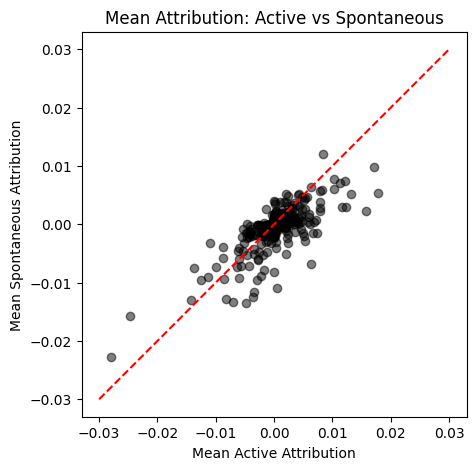

In [ ]:
# import min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
relative_attr = broadband_attr / np.sum(np.abs(broadband_attr), axis=1, keepdims=True)
mean_active_attr = np.nanmean(relative_attr, axis=0)
mean_spontaneous_attr = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\avr_attrs\1044385384_attribution_scores_spontaneous_mean.npy')
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# ax.scatter(scaler.fit_transform(mean_active_attr.reshape(-1, 1)), scaler.fit_transform(mean_spontaneous_attr[5,0,:].reshape(-1, 1)), c='k', alpha=0.5)
ax.scatter(mean_active_attr, mean_spontaneous_attr[5,0,:], c='k', alpha=0.5)
ax.set_xlabel('Mean Active Attribution')
ax.set_ylabel('Mean Spontaneous Attribution')
ax.set_title('Mean Attribution: Active vs Spontaneous')
ax.plot([-0.03, 0.03], [-0.03, 0.03], 'r--')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
plt.savefig(output_dir_plots / 'active_vs_spontaneous_attr.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

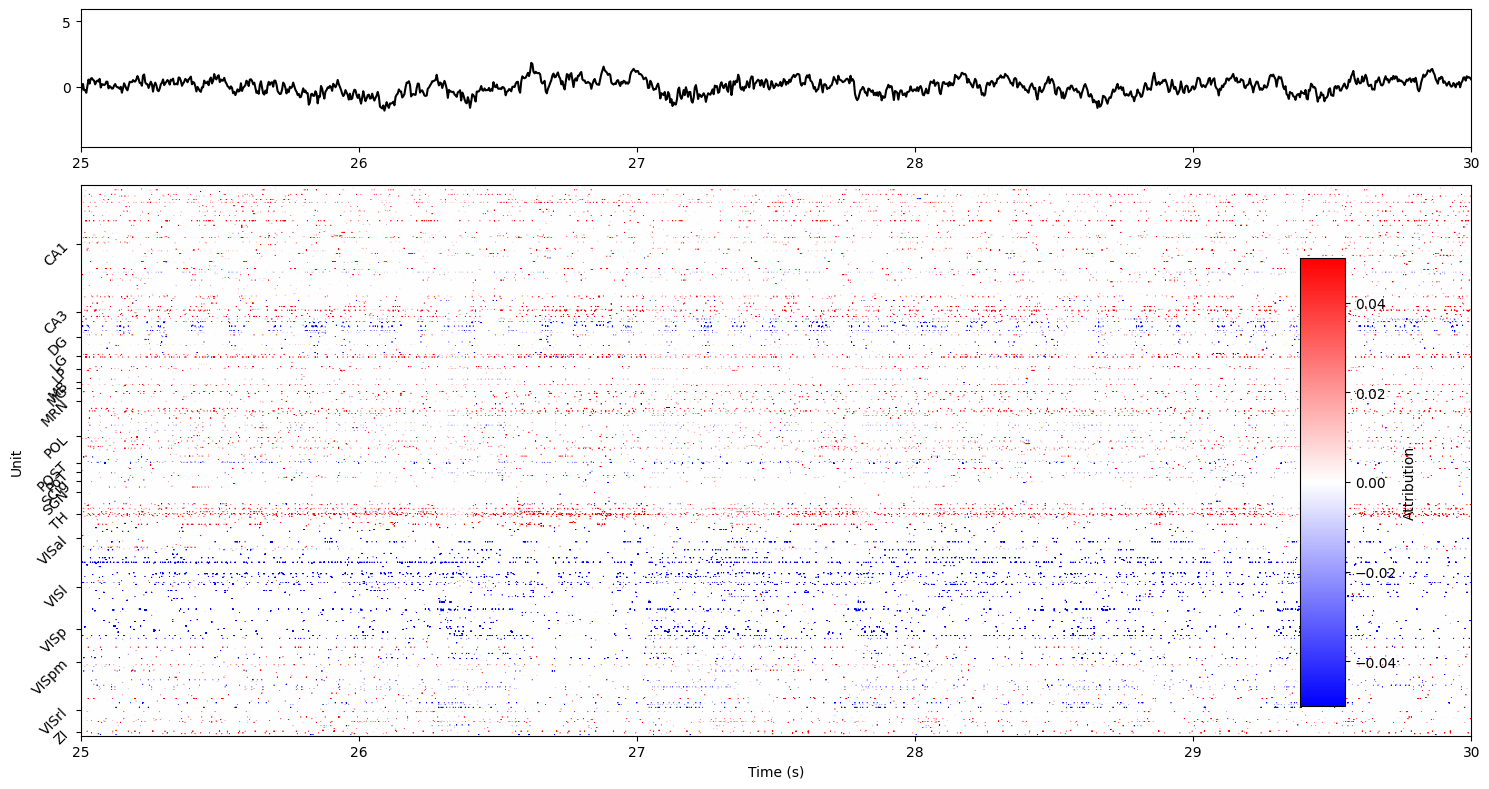

In [199]:
import importlib
import plots
importlib.reload(plots)
from plots import *

relative_attr = broadband_attr / np.sum(np.abs(broadband_attr), axis=1, keepdims=True)
lfp = lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0]
plot_attr_matrix(relative_attr, lfp, spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0] + attr_dur], save_fig=True, output_dir=output_dir_plots)

(25.0, 30.0)

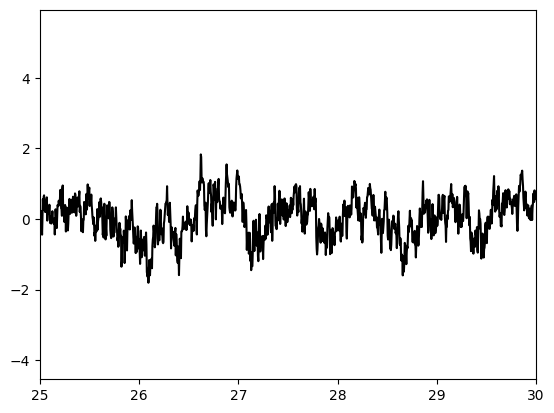

In [201]:
plt.plot(spikes_obj.timestamps[:int(attr_dur/bin_size)], lfp, 'k')
plt.xlim([spikes_obj.timestamps[0], spikes_obj.timestamps[0] + 5])

In [ ]:
# # for each neuron, calculate the correlation between the attribution scores and the firing rate
# unit_attr_fr_corr = np.zeros( (input_size ,num_channels, len(bands)+1))

# for bandi in range(len(bands)+1):
#     for chani in range(num_channels):
#         filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npy'
#         attr = np.load(filename)
#         mean1 = np.mean(attr.T, axis=1, keepdims=True)
#         mean2 = np.mean(spikes_obj.spkMat[:int(attr_dur/bin_size),:].T, axis=1, keepdims=True)
#         centered1 = attr.T - mean1
#         centered2 = spikes_obj.spkMat[:int(attr_dur/bin_size),:].T - mean2
#         covariance = np.sum(centered1 * centered2, axis=1)
#         std1 = np.sqrt(np.sum(centered1**2, axis=1))
#         std2 = np.sqrt(np.sum(centered2**2, axis=1))
#         unit_attr_fr_corr[:, chani, bandi] = covariance / (std1 * std2)  

In [53]:
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
max_neuron = np.argmax(np.mean(np.abs(broadband_attr),axis=0)) 
print(f'Max neuron in channel 5: {max_neuron}')

Max neuron in channel 5: 216


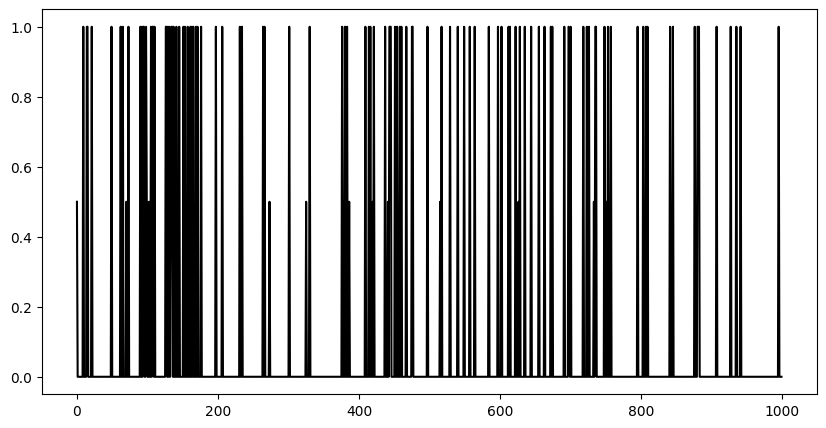

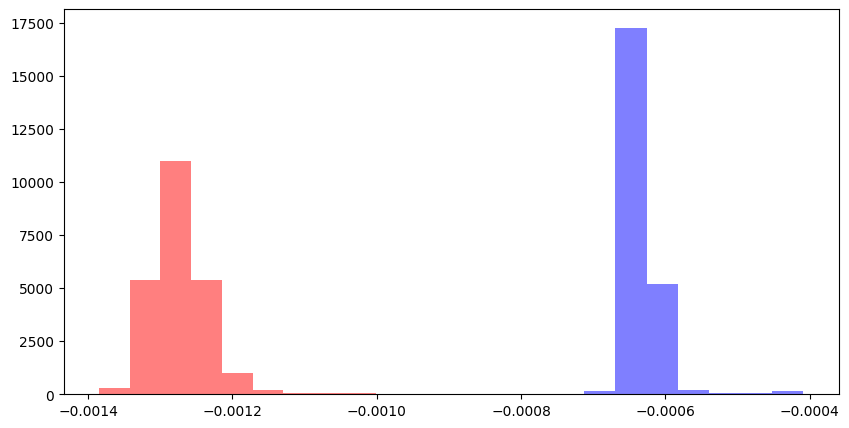

In [134]:
# plot the firing of neuron 216 (max attribution neuron)
celli=209

_, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(X_attr[0:1000,celli].cpu().detach().numpy(),color='k')
plt.show()

_, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(broadband_attr[:,celli][X_attr[:,celli].cpu().detach().numpy()==1],color='r', alpha=.5, density=True)
ax.hist(broadband_attr[:,celli][(X_attr[:,celli].cpu().detach().numpy()>0.3) & (X_attr[:,celli].cpu().detach().numpy()<0.8)],color='b', alpha=.5,density=True)
plt.show()

In [93]:
attr_dur = 720
mean_snippet_allchan = np.zeros((num_channels, 188, spikes_obj.spkMat.shape[1]))
mean_lfp_snippet_allchan = np.zeros((num_channels, 188))
neuron_channel_corr = np.zeros((num_channels, spikes_obj.spkMat.shape[1]))

# plot_unit_attr_fr_corr(unit_attr_fr_corr, session_obj, bands)
for chani in range(num_channels):
    broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npy')
    attr_snippets, lfp_snippets, t = plot_peri_stim_attr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj,
                        spikes_obj.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5], show_plot=False)
    mean_snippets = np.mean(attr_snippets, axis=0)
    mean_lfp_snippet_allchan[chani,:] = np.mean(lfp_snippets, axis=0)
    mean_snippet_allchan[chani,:,:] = mean_snippets
    for uniti in range(spikes_obj.spkMat.shape[1]):
        corr = np.corrcoef(broadband_attr[:,uniti], spikes_obj.spkMat[:int(attr_dur/bin_size),uniti])[0,1]
        neuron_channel_corr[chani, uniti] = corr


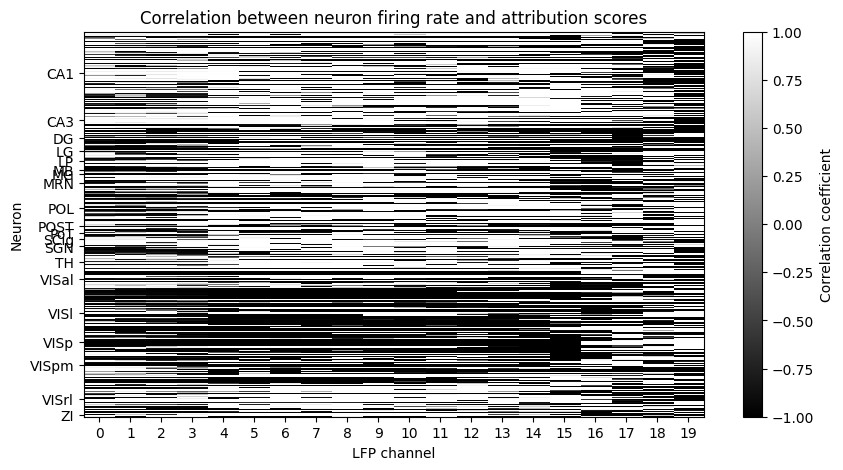

In [55]:
locs = session_obj.units['structure_acronym']
sidx = np.argsort(locs.values)
sorted_locs = locs.values[sidx]

# for each area, find the first and last unit
areas = np.unique(sorted_locs)
first = []
last  = []
for area in areas:
    ind = sorted_locs == area
    first.append(np.where(ind)[0][0])
    last.append(np.where(ind)[0][-1])
middle = (np.array(first) + (np.array(last) - np.array(first)) / 2).astype(int)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(neuron_channel_corr[:,sidx].T, aspect='auto', cmap='gray', vmin=-1, vmax=1, interpolation='none')
ax.set_xlabel('LFP channel')
ax.set_ylabel('Neuron')
ax.set_title('Correlation between neuron firing rate and attribution scores')
ax.set_xticks(np.arange(num_channels))
ax.set_yticks(middle)
ax.set_yticklabels(areas)
cbar = plt.colorbar(mappable=ax.images[0], ax=ax)
cbar.set_label('Correlation coefficient')
plt.show()

In [94]:
# calculate the CSD of the LFP snippets
timestamps = spikes_obj.timestamps[:int(attr_dur/bin_size)]
stim_st = session_obj.stimulus_presentation.start_time
stim_st = stim_st[((stim_st - np.abs(t[0])) > timestamps[0]) & ((stim_st + np.abs(t[-1])) < timestamps[-1])]
stim_st = stim_st.values

csd = np.diff(np.diff(lfp_obj.lfpMat[:int(attr_dur/bin_size),:,0], axis=1), axis=1)
csd_snippets = np.zeros((csd.shape[1], 188))
for i in range(len(stim_st)):
    start = np.argmin(np.abs(timestamps - (stim_st[i]- np.abs(t[0])  )))
    csd_snippets += csd[start:start+len(t),:].T
csd_snippets /= len(stim_st)

# calculate the PSTHs of all neurons
psth = np.zeros((spikes_obj.spkMat.shape[1], 188))
for i in range(len(stim_st)):
    start = np.argmin(np.abs(timestamps - (stim_st[i]- np.abs(t[0])  )))
    psth += spikes_obj.spkMat[start:start+len(t),:].T
psth /= len(stim_st)

In [138]:
# find the 10 neurons with highest mean absolute attribution in channel 5 broadband
mean_abs_attribution = np.mean(np.abs(broadband_attr), axis=0)
top_neurons = np.argsort(mean_abs_attribution)[-10:]
print(f'Top 10 neurons with highest mean absolute attribution in channel 5 broadband: {top_neurons}')

Top 10 neurons with highest mean absolute attribution in channel 5 broadband: [479 564 383 311 387 352 100 195 271 353]


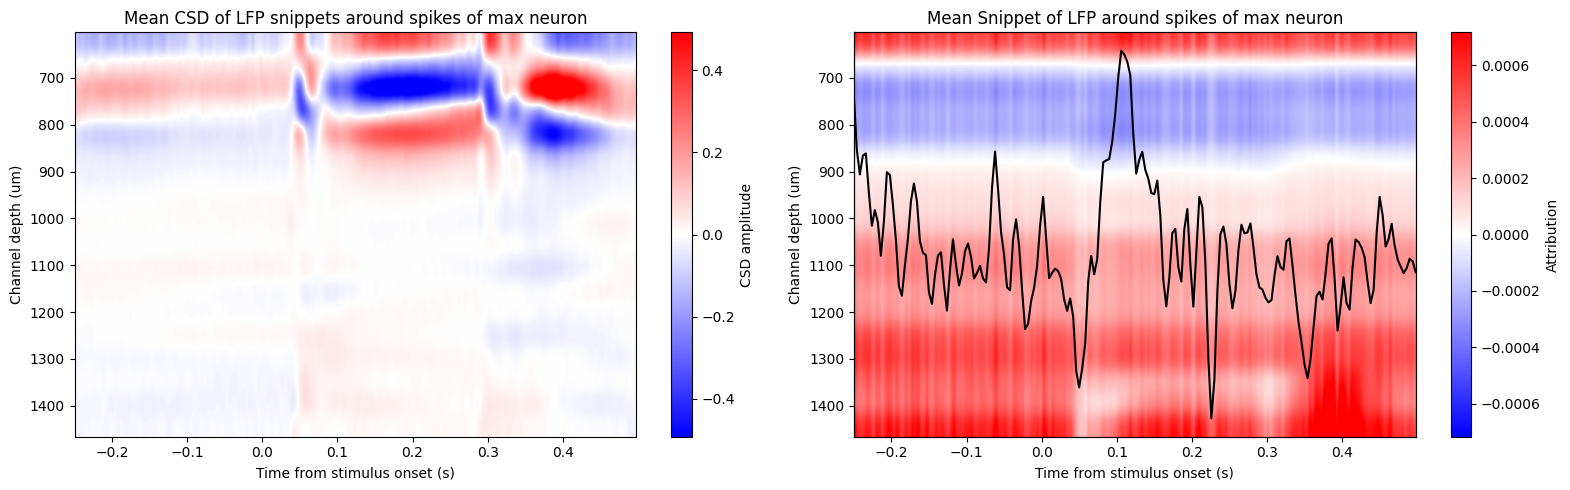

In [143]:
# plot mean_snippet_allchan for unit 18 and the CSD
from scipy.ndimage import gaussian_filter

celli = 311   
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
im = ax[0].imshow(csd_snippets, aspect='auto', cmap='bwr', interpolation='gaussian',
                vmin=-np.max(np.abs(csd_snippets))/2, vmax=np.max(np.abs(csd_snippets))/2,
                extent = [t[0], t[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[1]])
ax[0].invert_yaxis()
ax[0].set_xlabel('Time from stimulus onset (s)')
ax[0].set_ylabel('Channel depth (um)')
ax[0].set_title('Mean CSD of LFP snippets around spikes of max neuron')
plt.colorbar(im, ax=ax[0], label='CSD amplitude')

im = ax[1].imshow(mean_snippet_allchan[1:-1,:,celli], aspect='auto', cmap='bwr', interpolation='gaussian', 
           vmin=-np.max(np.abs(mean_snippet_allchan[:,:,celli]))/1.5, 
           vmax=np.max(np.abs(mean_snippet_allchan[:,:,celli]))/1.5,
           extent=[t[0], t[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[1]])
ax[1].invert_yaxis()
ax[1].set_xlabel('Time from stimulus onset (s)')
ax[1].set_ylabel('Channel depth (um)')
ax[1].set_title('Mean Snippet of LFP around spikes of max neuron')
plt.colorbar(im, ax=ax[1], label='Attribution')
# overlay the neuron's psth on top of the right plot
ax2 = ax[1].twinx()
ax2.plot(t, gaussian_filter(psth[celli,:], sigma=1), 'k')
ax2.set_yticks([])
plt.tight_layout()
# plt.savefig(output_dir_plots / 'CSD_attr_cell479.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

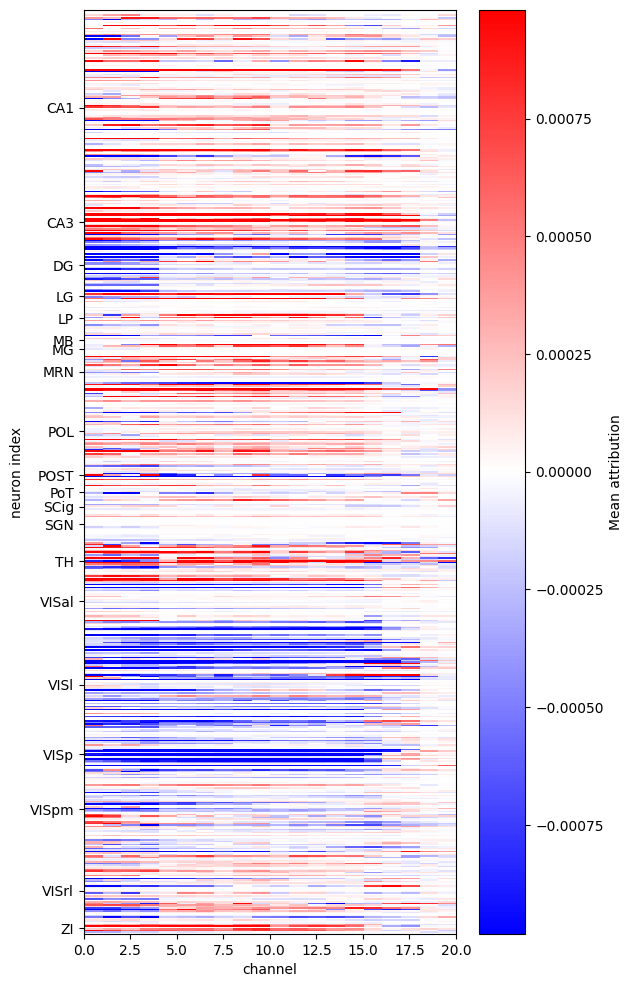

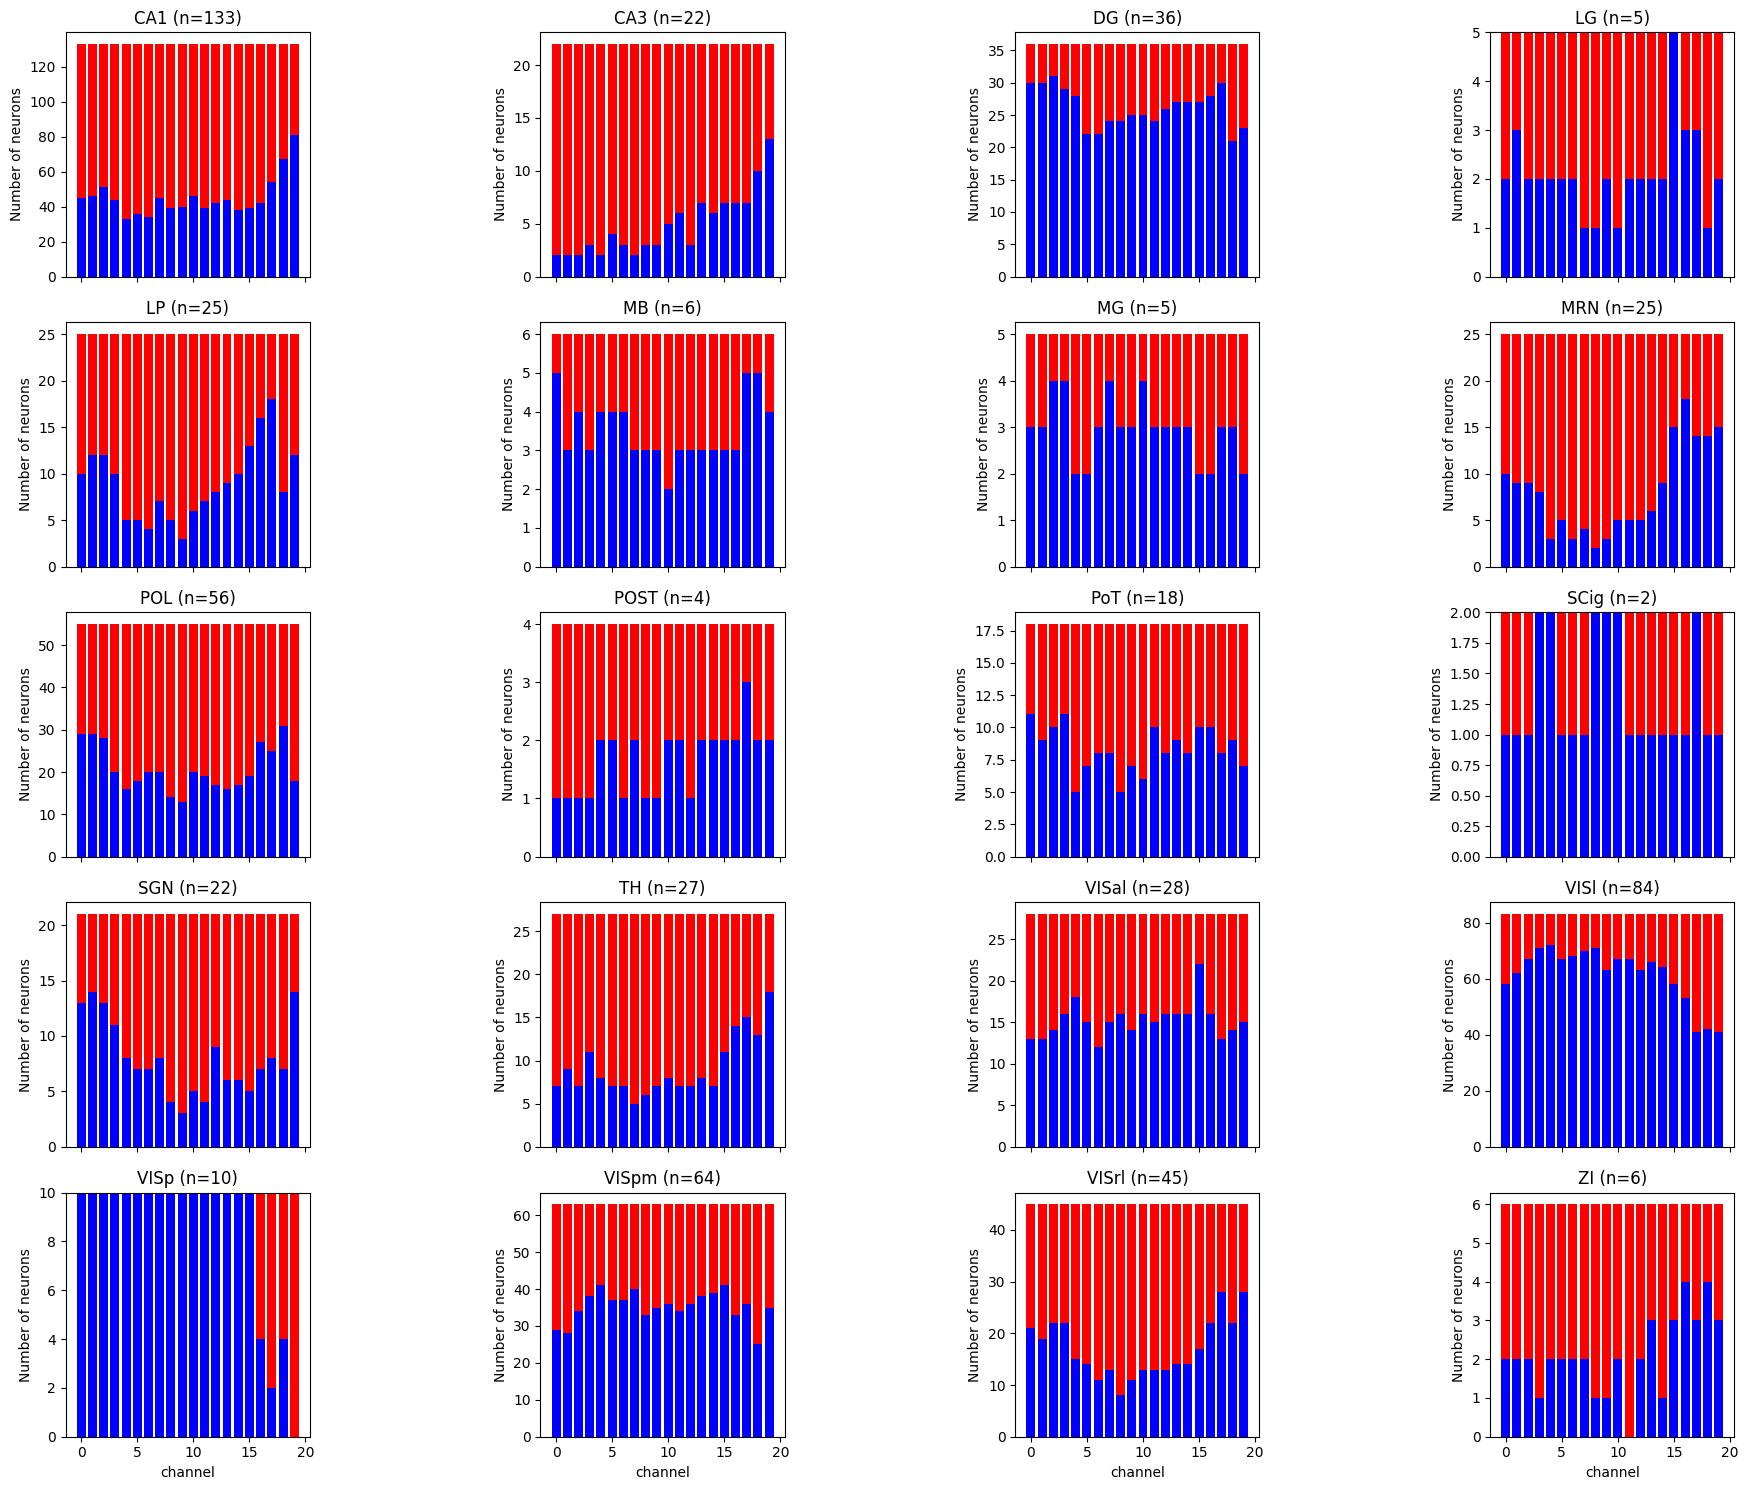

In [84]:
locs = session_obj.units['structure_acronym']
sidx = np.argsort(locs.values)
sorted_locs = locs.values[sidx]

# for each area, find the first and last unit
areas = np.unique(sorted_locs)
first = []
last  = []
for area in areas:
    ind = sorted_locs == area
    first.append(np.where(ind)[0][0])
    last.append(np.where(ind)[0][-1])
middle = (np.array(first) + (np.array(last) - np.array(first)) / 2).astype(int)

# calculate the mean attribution across all channels
mean_attr_allchan = np.mean(mean_snippet_allchan, axis=1)

# plot mean_attr_allchan for all neurons
fig, ax = plt.subplots(1, 1, figsize=(6, 12))
im = ax.imshow(mean_attr_allchan[:,sidx].T, aspect='auto', cmap='bwr', interpolation='none', 
           vmin=-np.max(np.abs(mean_attr_allchan))/10, 
           vmax=np.max(np.abs(mean_attr_allchan))/10,
           extent=[0, mean_attr_allchan.shape[0], mean_attr_allchan.shape[1], 0])
ax.set_xlabel('channel')
ax.set_ylabel('neuron index')
ax.set_yticks(middle)
ax.set_yticklabels(areas)
cbar = plt.colorbar(mappable=ax.images[0], ax=ax)
cbar.set_label('Mean attribution')
plt.show()

# get the polarity of each neuron at each channel

# plot the above histogram for each area
fig, ax = plt.subplots(int(len(areas)/4), 4, figsize=(20, 15), sharex=True)
for areai, area in enumerate(areas):
    axr = ax[int(areai/4), areai%4]
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    mean_attr_area = mean_attr_allchan[:,ind]
    # axr.hist(np.sum(np.sign(mean_attr_area) < 0, axis=1), bins=np.arange(num_channels+1)-0.5, color='b', alpha=0.7)
    # axr.hist(np.sum(np.sign(mean_attr_area) > 0, axis=1), bins=np.arange(num_channels+1)-0.5, color='r', alpha=0.7)
    sum_neg = np.sum(np.sign(mean_attr_area) < 0, axis=1)
    axr.bar(np.arange(len(sum_neg)), sum_neg, color='b')
    sum_pos = np.sum(np.sign(mean_attr_area) > 0, axis=1)
    axr.bar(np.arange(len(sum_pos)), sum_pos, bottom=sum_neg, color='r')
    axr.set_title(area + ' (n=' + str(sum(ind)) + ')')
    axr.set_aspect(1.0/axr.get_data_ratio(), adjustable='box')
    # if its the bottom row, add x label
    if areai >= (int(len(areas)/4)-1)*4:
        axr.set_xlabel('channel')
    axr.set_ylabel('Number of neurons')
plt.tight_layout()
plt.show()

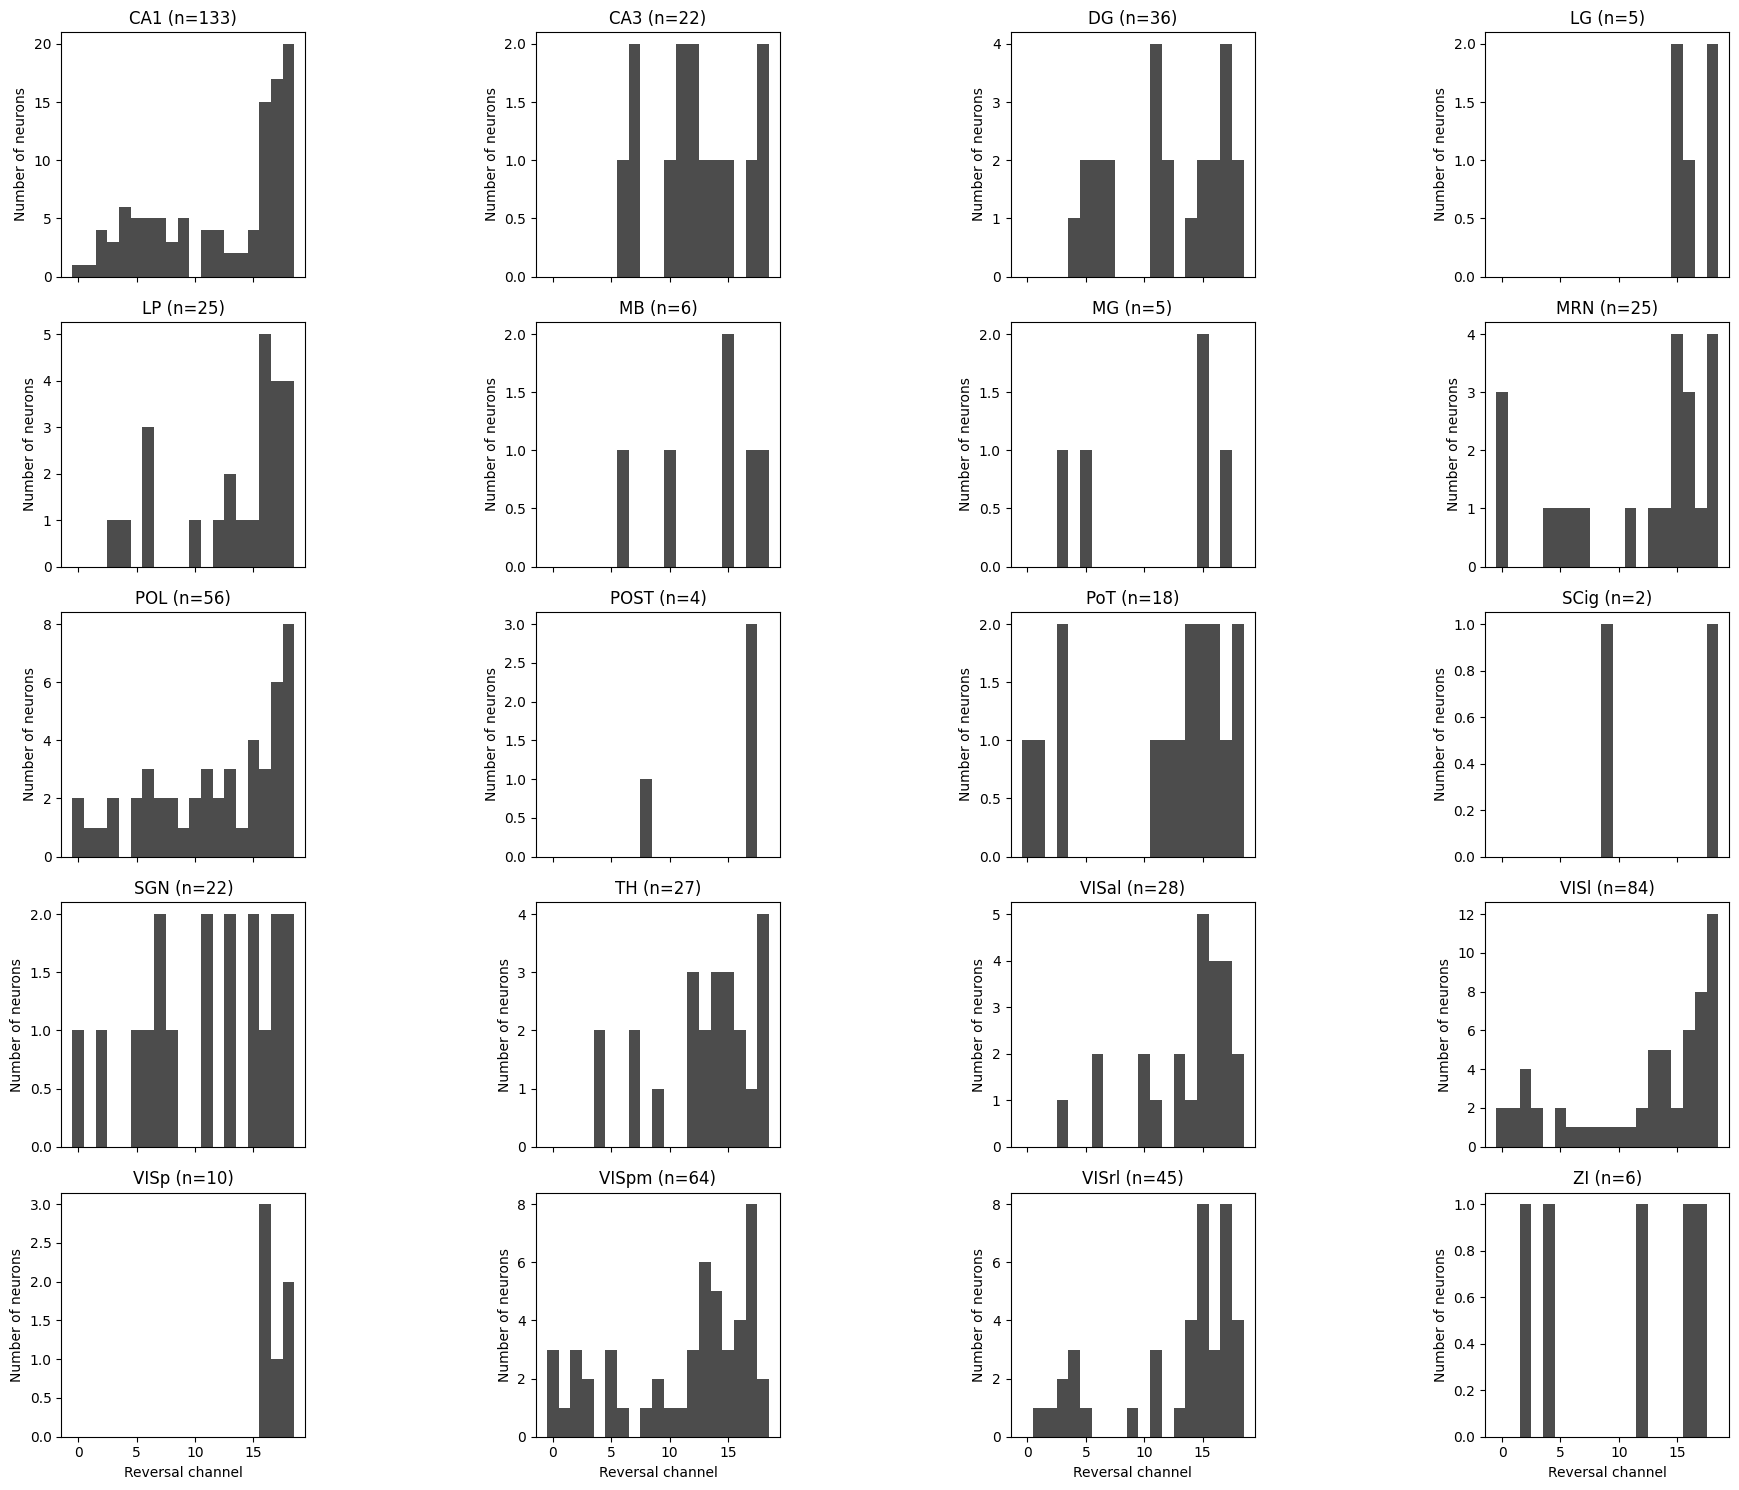

In [85]:
# smooth mean_snippet_allchan by convolving with a 2d gaussian
from scipy.ndimage import gaussian_filter
mean_snippet_allchan_smooth = np.zeros_like(mean_snippet_allchan)
for celli in range(mean_snippet_allchan.shape[2]):
    mean_snippet_allchan_smooth[:,:,celli] = gaussian_filter(mean_snippet_allchan[:,:,celli], sigma=(1, 1))
mean_attr_allchan_smooth = np.mean(mean_snippet_allchan_smooth, axis=1)
    
# for each neuron, find the channel that is closest to 0, ie the reversal channel
reversal_channel = np.zeros(spikes_obj.spkMat.shape[1])
for i in range(spikes_obj.spkMat.shape[1]):
    reversal_channel[i] = np.argmin(np.abs(mean_attr_allchan_smooth[:, i]))
# plot the histogram of reversal channels for each area
fig, ax = plt.subplots(int(len(areas)/4), 4, figsize=(20, 15), sharex=True)
for areai, area in enumerate(areas):
    axr = ax[int(areai/4), areai%4]
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    rev_area = reversal_channel[ind]
    axr.hist(rev_area, bins=np.arange(num_channels)-0.5, color='k', alpha=0.7)
    axr.set_title(area + ' (n=' + str(sum(ind)) + ')')
    axr.set_aspect(1.0/axr.get_data_ratio(), adjustable='box')
    # if its the bottom row, add x label
    if areai >= (int(len(areas)/4)-1)*4:
        axr.set_xlabel('Reversal channel')
    axr.set_ylabel('Number of neurons')
plt.tight_layout()
plt.show()

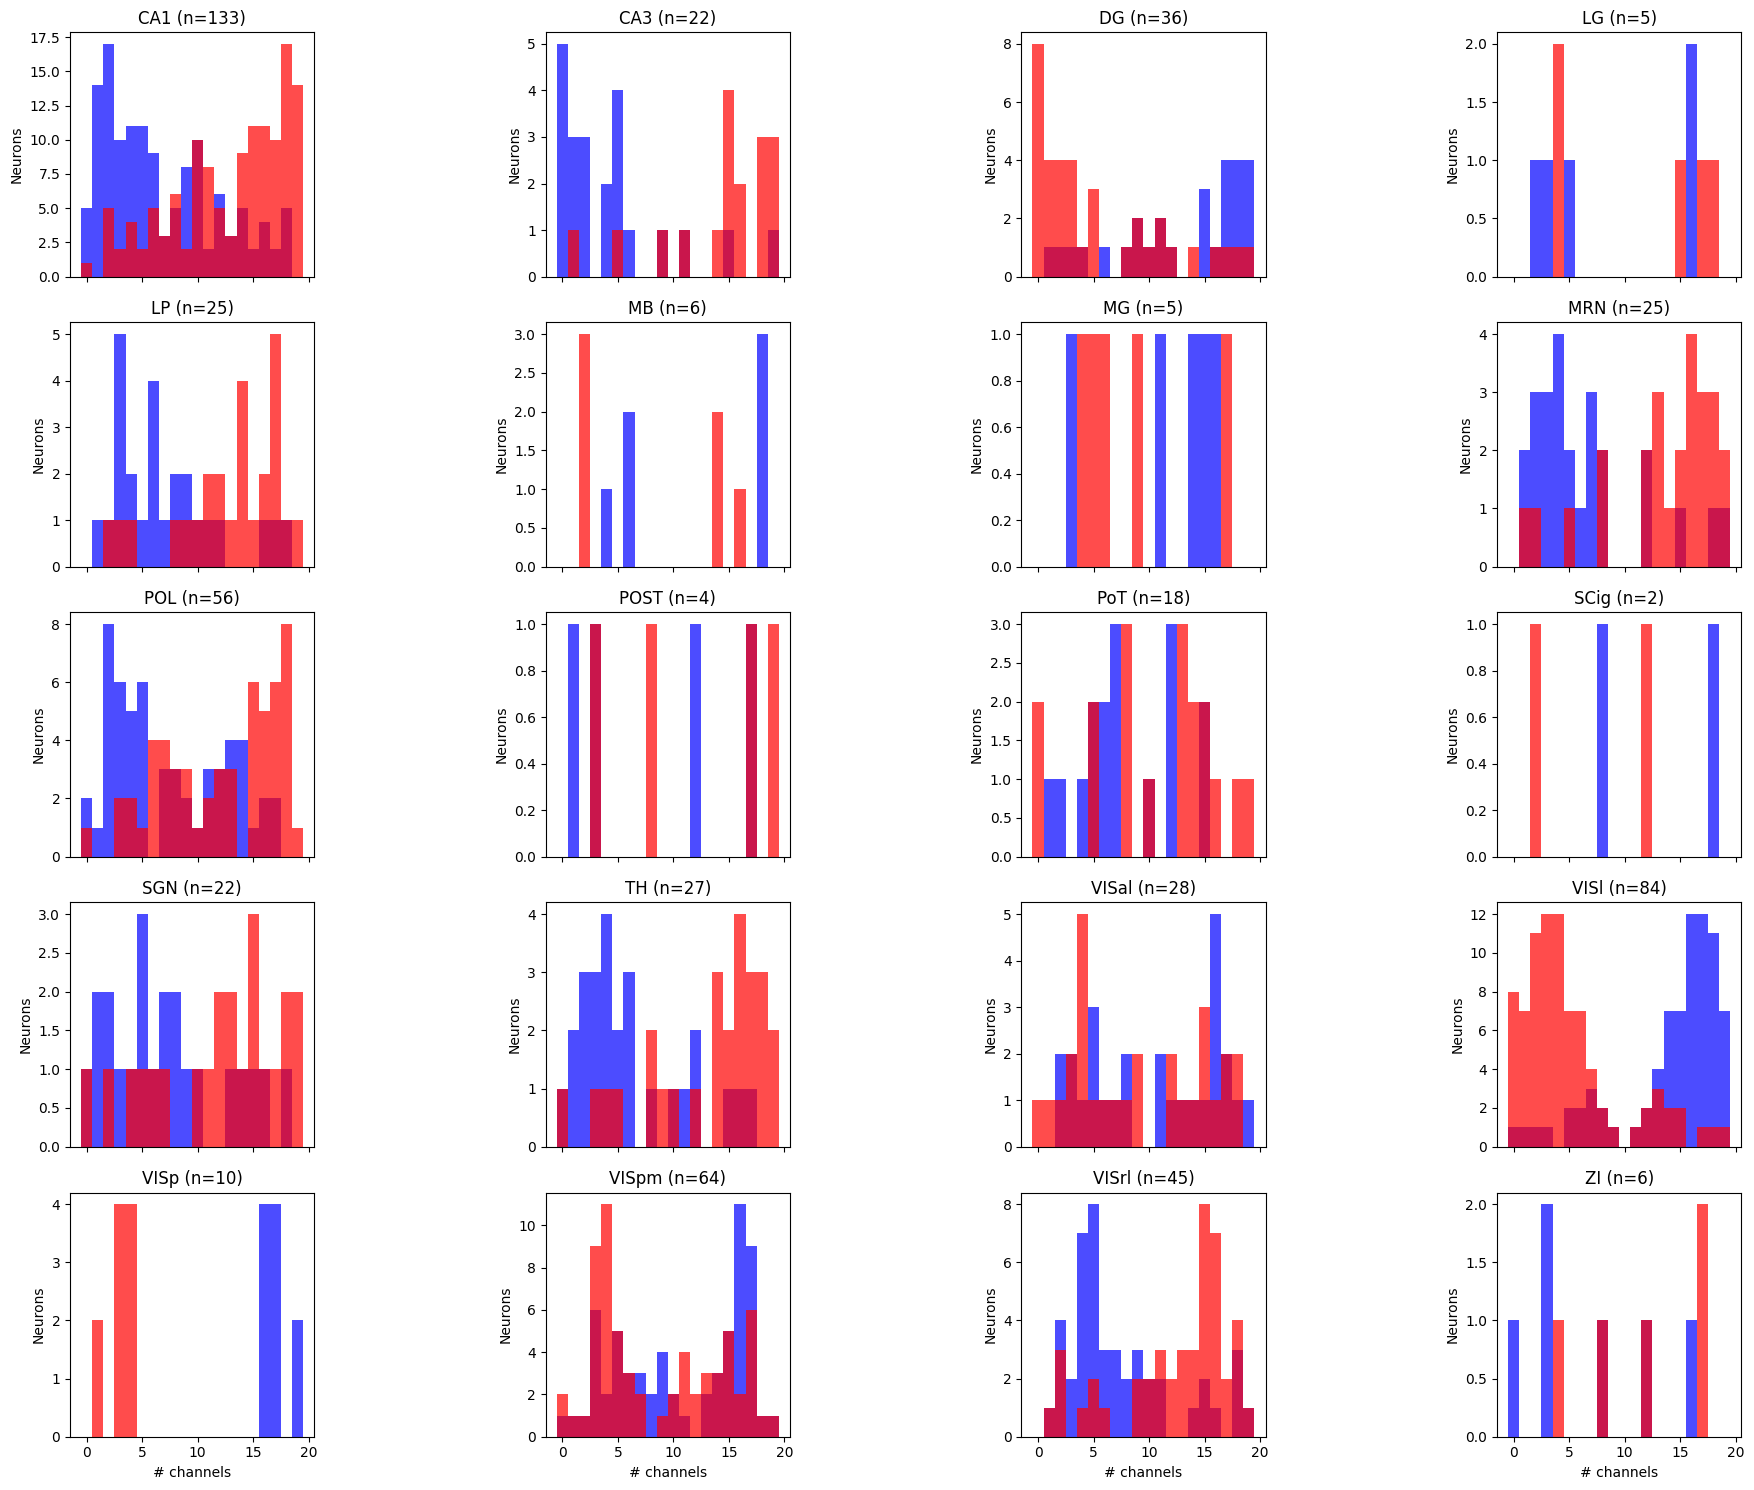

In [102]:
# for each neuron, calculate the number of channels with negative attribution
neuron_neg_attr = np.sum(np.sign(mean_attr_allchan) < 0, axis=0)
neuron_pos_attr = np.sum(np.sign(mean_attr_allchan) > 0, axis=0)

fig, ax = plt.subplots(int(len(areas)/4), 4, figsize=(20, 15), sharex=True)
for areai, area in enumerate(areas):
    axr = ax[int(areai/4), areai%4]
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    neuron_neg_attr_area = neuron_neg_attr[ind]
    neuron_pos_attr_area = neuron_pos_attr[ind]

    axr.hist(neuron_neg_attr_area, bins=np.arange(num_channels+1)-0.5, color='b', alpha=0.7)
    axr.hist(neuron_pos_attr_area, bins=np.arange(num_channels+1)-0.5, color='r', alpha=0.7)

    axr.set_title(area + ' (n=' + str(sum(ind)) + ')')
    axr.set_aspect(1.0/axr.get_data_ratio(), adjustable='box')
    if areai >= (int(len(areas)/4)-1)*4:
        axr.set_xlabel('# channels')
    axr.set_ylabel('Neurons')
plt.tight_layout()
plt.show()


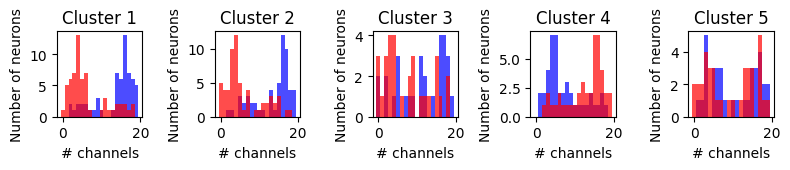

In [107]:
_, ax = plt.subplots(1, 5, figsize=(8, 6))
for clusteri in range(1, 6):
    ind = session_obj.units.index.isin(cluster_id[clusteri])
    neuron_neg_attr_cluster = neuron_neg_attr[ind]
    neuron_pos_attr_cluster = neuron_pos_attr[ind]

    ax[clusteri-1].hist(neuron_neg_attr_cluster, bins=np.arange(num_channels+1)-0.5, color='b', alpha=0.7)
    ax[clusteri-1].hist(neuron_pos_attr_cluster, bins=np.arange(num_channels+1)-0.5, color='r', alpha=0.7)
    ax[clusteri-1].set_xlabel('# channels')
    ax[clusteri-1].set_ylabel('Number of neurons')
    ax[clusteri-1].set_title(f'Cluster {clusteri}')
    
    # make the axis square
    ax[clusteri-1].set_aspect(1.0/ax[clusteri-1].get_data_ratio(), adjustable='box')

plt.tight_layout()
plt.show()


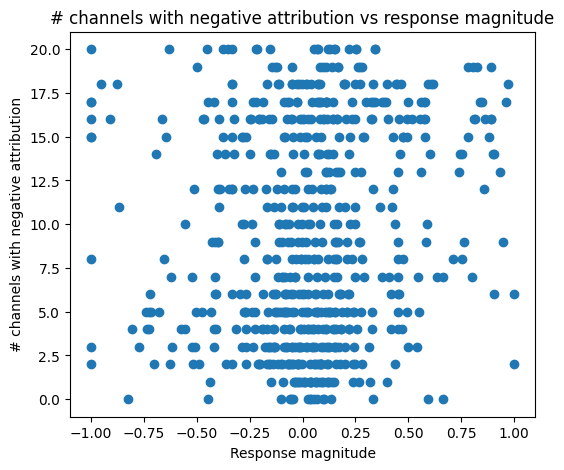

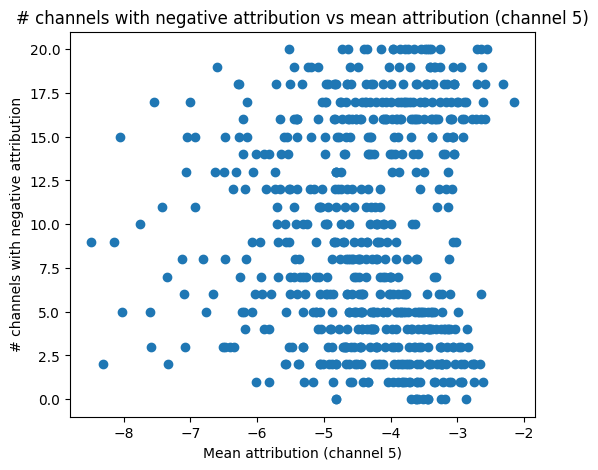

In [236]:

# plot the relationship between the number of channels with negative attribution and the response magnitude
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(df[df['session_id']==session_id]['response_mag'], neuron_neg_attr)
ax.set_xlabel('Response magnitude')
ax.set_ylabel('# channels with negative attribution')
ax.set_title('# channels with negative attribution vs response magnitude')
plt.show()

# broadband_attr_5 = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
# mean_attr_5 = np.mean(np.abs(broadband_attr_5), axis=0)
# plot the relationship between the number of channels with negative attribution and the mean attribution in channel 5
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(np.log10(mean_attr_5), neuron_neg_attr)
ax.set_xlabel('Mean attribution (channel 5)')
ax.set_ylabel('# channels with negative attribution')
ax.set_title('# channels with negative attribution vs mean attribution (channel 5)')
plt.show()

In [247]:
# Find indices of area neurons
ca1_mask = session_obj.units['structure_acronym'] == 'CA1'
ca1_indices = np.where(ca1_mask)[0]

# Compute mean absolute attribution for each CA1 neuron
ca1_attr = np.mean(np.abs(broadband_attr[:, ca1_mask]), axis=0)

# Find the index (within CA1) of the neuron with the highest attribution
max_idx_within_ca1 = np.argmax(ca1_attr)

# Get the global index of this neuron
max_ca1_neuron_idx = ca1_indices[max_idx_within_ca1]
print("Global index of CA1 neuron with highest attribution:", max_ca1_neuron_idx)

# find the cluster 4 cell with the highest attribution
clu_4_mask = session_obj.units.index.isin(cluster_id[4])
clu_4_indices = np.where(clu_4_mask)[0]
clu_4_attr = np.mean(np.abs(broadband_attr[:, clu_4_mask]), axis=0)
max_idx_within_clu4 = np.argmax(clu_4_attr)
print(f'max attrtibution cluster 4: {np.max(clu_4_attr)}')
max_clu4_neuron_idx = clu_4_indices[max_idx_within_clu4]
print("Global index of cluster 4 neuron with highest attribution:", max_clu4_neuron_idx)

Global index of CA1 neuron with highest attribution: 383
max attrtibution cluster 4: 0.00024085423501674086
Global index of cluster 4 neuron with highest attribution: 47


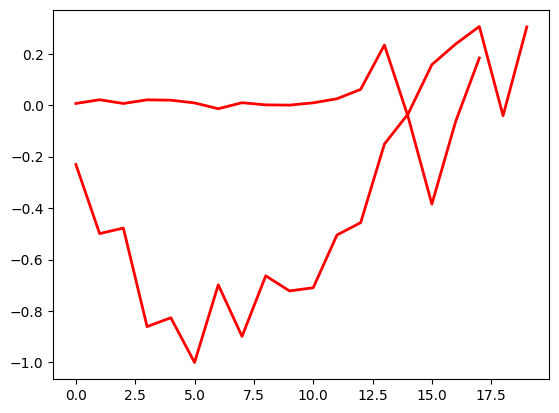

In [73]:
# for each cell, calculate the mean attribution across channels during stimulus presentation
mean_stim_attr_allchan = np.mean(mean_snippet_allchan[:, np.where(t > 0)[0][0]: np.where(t < .25)[0][-1] ,:], axis=1)
# do the same for the csd 
mean_stim_csd = np.mean(csd_snippets[:, np.where(t > 0)[0][0]: np.where(t < .25)[0][-1] ], axis=1)

# normalize each neuron's attribution vector by its maximum
mean_stim_attr_allchan = mean_stim_attr_allchan / np.max(np.abs(mean_stim_attr_allchan), axis=0, keepdims=True)
# # minmax normalize
# mean_stim_attr_allchan = (mean_stim_attr_allchan - np.min(mean_stim_attr_allchan)) / (np.max(mean_stim_attr_allchan) - np.min(mean_stim_attr_allchan))


# plt.plot(mean_stim_attr_allchan, 'k')
plt.plot(mean_stim_attr_allchan[:,celli], 'r', linewidth=2)
plt.plot(mean_stim_csd, 'r', linewidth=2)
# plt.plot(mean_stim_attr_allchan[:,session_obj.units.index.isin(cluster_id[1])], 'r', linewidth=2)
plt.show()

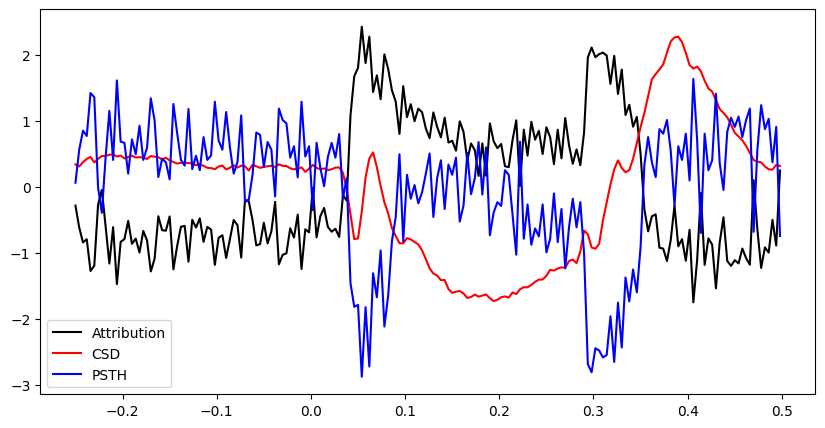

In [248]:
from scipy.stats import zscore

celli = 353

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t,zscore(mean_snippet_allchan[-3,:,celli]), 'k', label='Attribution')
ax.plot(t,zscore(csd_snippets[-3,:]), 'r', label='CSD')
ax.plot(t,zscore(psth[celli,:]), 'b', label='PSTH')
plt.legend()
plt.show()

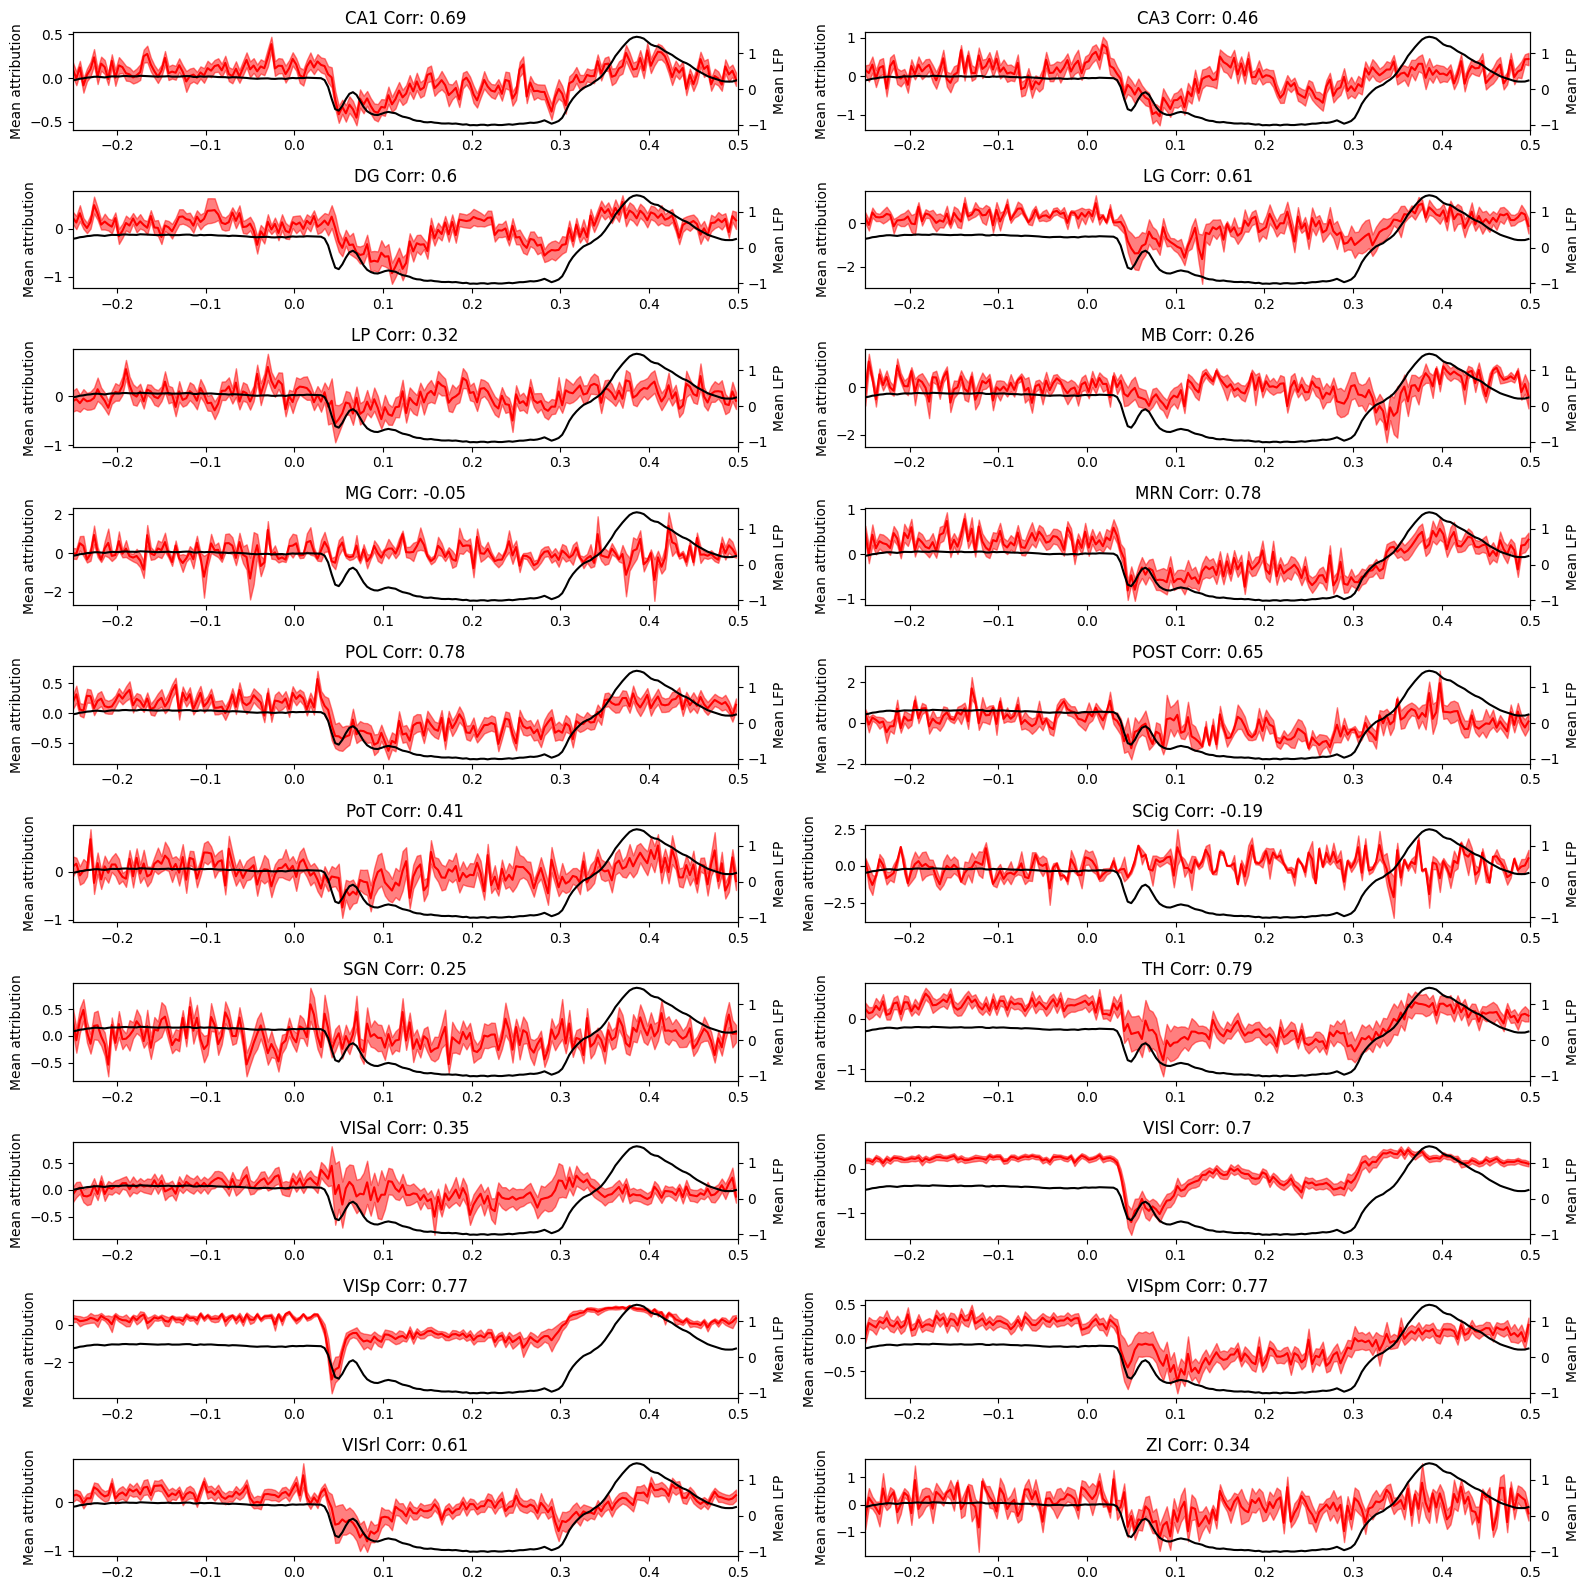

In [316]:
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
# plot_unit_attr_fr_corr(unit_attr_fr_corr, session_obj, bands)
attr_snippets, lfp_snippets, t = plot_peri_stim_attr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0], session_obj,
                    spikes_obj.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5])

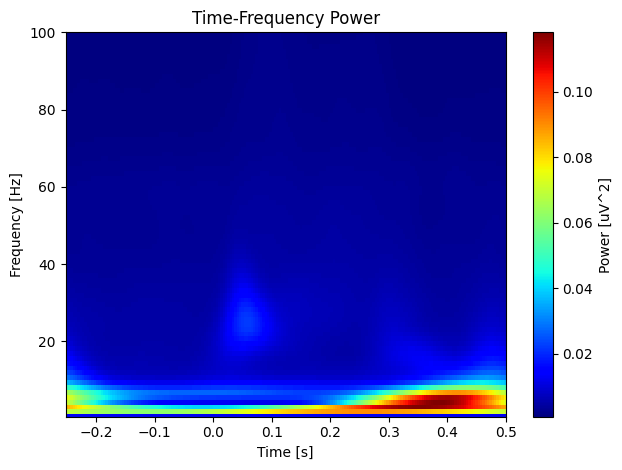

In [317]:
# compute wavelet spectrogram
import importlib
import wavelet_power
importlib.reload(wavelet_power)
from wavelet_power import wavelet_power

tf, tf_all, itpc, frex = wavelet_power(lfp_snippets.T, t, Fs=250, freqs=[0.5, 100], num_frex=80)


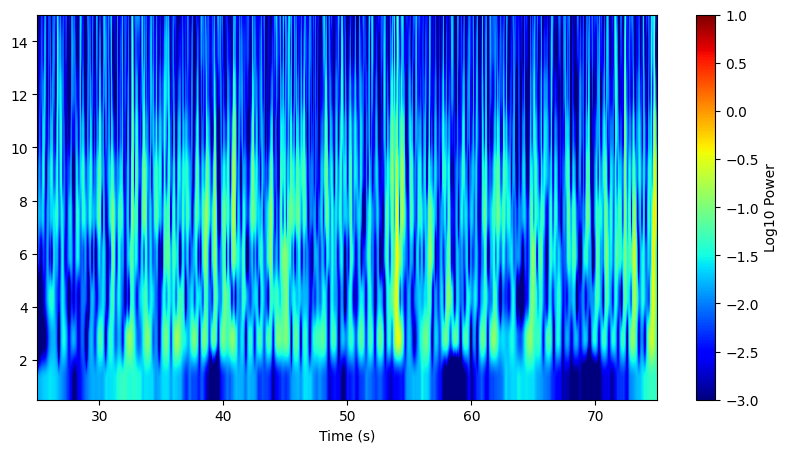

In [344]:
# compute a spectrogram for the entire attribution data
tf, tf_all, itpc, frex = wavelet_power(lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0].T.reshape(-1, 1), 
                                       spikes_obj.timestamps[:int(attr_dur/bin_size)], Fs=250, freqs=[0.5, 125], num_frex=80,
                                       normalization='none', mkplt=False)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(np.log10(tf), aspect='auto', origin='lower', 
                          extent=[spikes_obj.timestamps[:int(attr_dur/bin_size)][0], spikes_obj.timestamps[:int(attr_dur/bin_size)][-1], frex[0], frex[-1]], 
                          cmap='jet', vmin=-3, vmax=1)
ax.set_ylim(frex[0], 15)
ax.set_xlim(spikes_obj.timestamps[:int(attr_dur/bin_size)][0], spikes_obj.timestamps[:int(attr_dur/bin_size)][0]+50)
ax.set_xlabel('Time (s)')
plt.colorbar(im, ax=ax, label='Log10 Power')
plt.show()

In [365]:
chani = 5
bands_4_corr = bands[0:7]
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npy')
norm_power = np.zeros((len(bands_4_corr), len(spikes_obj.timestamps[:int(attr_dur/bin_size)])))
# for each frequency band, calculate the mean power during the attribution window
for i, band in enumerate(bands_4_corr):
    norm_power[i, :] = zscore(np.mean(tf[(frex >= band[0]) & (frex <= band[1]), :], axis=0))
    
attr_power_dp = np.zeros((broadband_attr.shape[1], len(bands_4_corr))) # dot product of attribution and power
for uniti in range(broadband_attr.shape[1]):
    for bandi in range(len(bands_4_corr)):
        attr_power_dp[uniti, bandi] = np.dot(broadband_attr[:, uniti], norm_power[bandi, :])



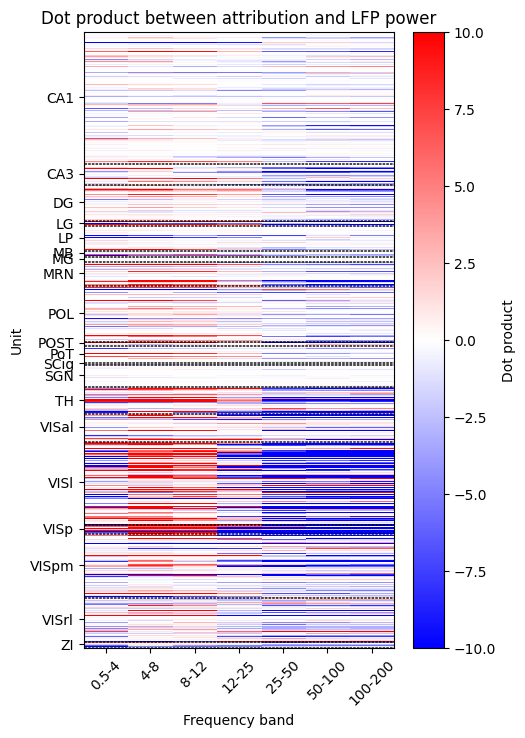

In [372]:
locs = session_obj.units['structure_acronym']
sidx = np.argsort(locs.values)
sorted_locs = locs.values[sidx]

# for each area, find the first and last unit
areas = np.unique(sorted_locs)
first = []
last  = []
for area in areas:
    ind = sorted_locs == area
    first.append(np.where(ind)[0][0])
    last.append(np.where(ind)[0][-1])
middle = (np.array(first) + (np.array(last) - np.array(first)) / 2).astype(int)


fig, ax = plt.subplots(1, 1, figsize=(5,8))
im = ax.imshow(attr_power_dp[sidx,:], aspect='auto', cmap='bwr', vmin=-10, vmax=10, interpolation='none',
               extent=[0,7,broadband_attr.shape[1],0])
cbar = plt.colorbar(mappable=im, ax=ax)
cbar.set_label('Dot product')
ax.set_yticks(middle)
ax.set_yticklabels(areas)
ax.set_xticks(np.arange(0, 7, 1)+0.5)
ax.set_xticklabels(['0.5-4','4-8','8-12','12-25','25-50','50-100','100-200'], rotation=45)
ax.set_xlabel('Frequency band')
ax.set_ylabel('Unit')
ax.set_title('Dot product between attribution and LFP power')

# Add horizontal lines for area boundaries
for idx in first + last:
    ax.axhline(idx, color='k', linestyle='--', linewidth=.5)


plt.show()


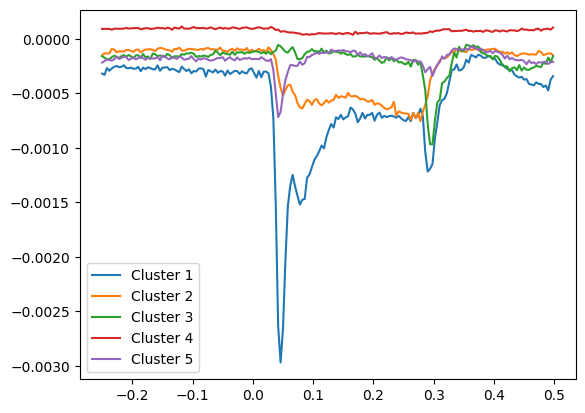

In [54]:
mean_snippets = np.mean(attr_snippets, axis=0)
mean_clu1 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[1])] , axis=1)
mean_clu2 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[2])] , axis=1)
mean_clu3 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[3])] , axis=1)
mean_clu4 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[4])] , axis=1)
mean_clu5 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[5])] , axis=1) 

plt.plot(t, mean_clu1, label='Cluster 1')
plt.plot(t, mean_clu2, label='Cluster 2')
plt.plot(t, mean_clu3, label='Cluster 3')   
plt.plot(t, mean_clu4, label='Cluster 4')
plt.plot(t, mean_clu5, label='Cluster 5')
plt.legend()
plt.show()


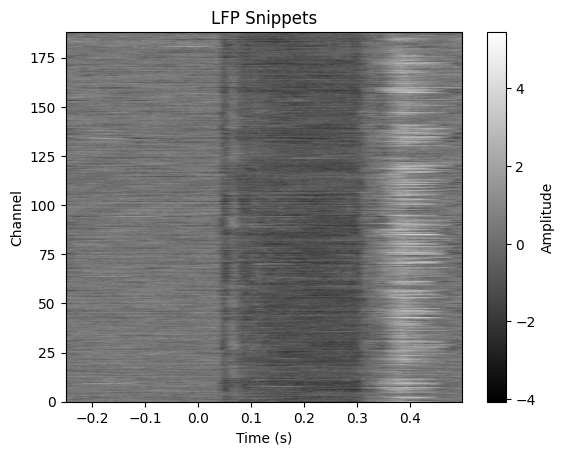

In [ ]:
plt.imshow(lfp_snippets, aspect='auto', cmap='gray', extent=[t[0], t[-1], 0, lfp_snippets.shape[1]])
plt.xlabel('Time (s)')
plt.ylabel('Channel')
plt.title('LFP Snippets')
plt.colorbar(label='Amplitude')
plt.show()

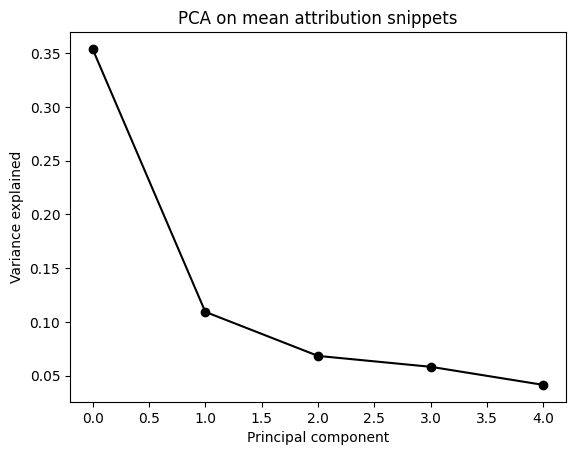

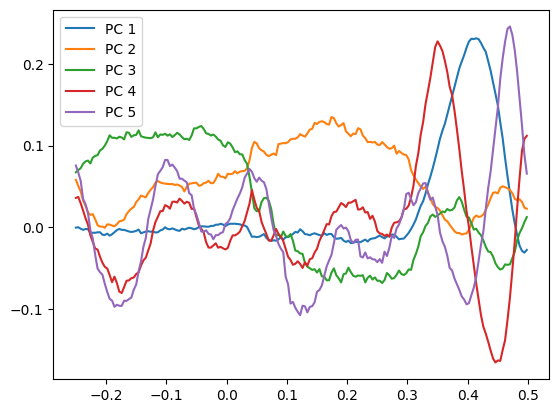

In [65]:
# run a PCA on mean_lfp_snippets to extract the dominant patterns of attribution around stimulus onset
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca.fit(lfp_snippets)
pca_components = pca.components_
plt.plot(pca.explained_variance_ratio_, 'ko-')
plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.title('PCA on mean attribution snippets')
plt.show()

plt.plot(t, pca_components[0,:], label='PC 1')
plt.plot(t, pca_components[1,:], label='PC 2')
plt.plot(t, pca_components[2,:], label='PC 3')
plt.plot(t, pca_components[3,:], label='PC 4') 
plt.plot(t, pca_components[4,:], label='PC 5')
plt.legend()
plt.show()

In [81]:
# unsupervised discovery of LFP patterns using CNN autoencoder
import torch.nn as nn

class CNNAutoencoder(nn.Module):
    def __init__(self, input_size, latent_dim):
        super(CNNAutoencoder, self).__init__()
        self.input_size = input_size

        # Calculate output length after each layer
        def calc_out_len(l_in, kernel_size, stride, padding=0):
            return (l_in + 2 * padding - (kernel_size - 1) - 1) // stride + 1

        # After first Conv1d (padding=1, kernel_size=3, stride=1)
        l1 = calc_out_len(input_size, kernel_size=3, stride=1, padding=1)
        # After first MaxPool1d (kernel_size=2, stride=2)
        l2 = calc_out_len(l1, kernel_size=2, stride=2)
        # After second Conv1d (padding=1, kernel_size=3, stride=1)
        l3 = calc_out_len(l2, kernel_size=3, stride=1, padding=1)
        # After second MaxPool1d (kernel_size=2, stride=2)
        l4 = calc_out_len(l3, kernel_size=2, stride=2)
        self.pool_out_len = l4

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(32 * self.pool_out_len, latent_dim),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * self.pool_out_len),
            nn.ReLU(),
            nn.Unflatten(dim=1, unflattened_size=(32, self.pool_out_len)),
            nn.ConvTranspose1d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        # Crop or pad to match input size
        if decoded.shape[2] > self.input_size:
            decoded = decoded[:, :, :self.input_size]
        elif decoded.shape[2] < self.input_size:
            pad_size = self.input_size - decoded.shape[2]
            decoded = nn.functional.pad(decoded, (0, pad_size))
        return decoded
    
num_timepoints = len(lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0])
n_epochs = 20
num_batches = 50
input_size = seqlength
latent_dim = 5
model = CNNAutoencoder(input_size, latent_dim)
model.to(device)

X_train = np.array(np.split(lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0], int(num_timepoints/seqlength)))
X_train = torch.from_numpy(X_train).float().to(device)
X_train = torch.unsqueeze(X_train, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for i in range(num_batches):
        optimizer.zero_grad()
        batch = X_train[i * (X_train.shape[0] // num_batches):(i + 1) * (X_train.shape[0] // num_batches)]
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {running_loss / num_batches:.4f}')
    
#Load each array for plotting
results = np.empty((len(X_train), len(X_train[0][0])))
with torch.no_grad():
    for i in range (len(X_train)):
        testArray = model(X_train[i].unsqueeze(0))
        array = testArray.squeeze().cpu().numpy()
        results[i] = array
        
#   # plot results
# for result in results:
#     plt.plot(result)
#     plt.ylabel ("LFP approximation")
#     plt.xlabel("time_relative_to_spike")
#     plt.show()    

Epoch [1/20], Loss: 0.9299
Epoch [2/20], Loss: 0.8810
Epoch [3/20], Loss: 0.7895
Epoch [4/20], Loss: 0.6786
Epoch [5/20], Loss: 0.5962
Epoch [6/20], Loss: 0.5409
Epoch [7/20], Loss: 0.5280
Epoch [8/20], Loss: 0.5057
Epoch [9/20], Loss: 0.4935
Epoch [10/20], Loss: 0.4897
Epoch [11/20], Loss: 0.5046
Epoch [12/20], Loss: 0.4832
Epoch [13/20], Loss: 0.4888
Epoch [14/20], Loss: 0.4780
Epoch [15/20], Loss: 0.4768
Epoch [16/20], Loss: 0.4722
Epoch [17/20], Loss: 0.4796
Epoch [18/20], Loss: 0.4581
Epoch [19/20], Loss: 0.4593
Epoch [20/20], Loss: 0.4531


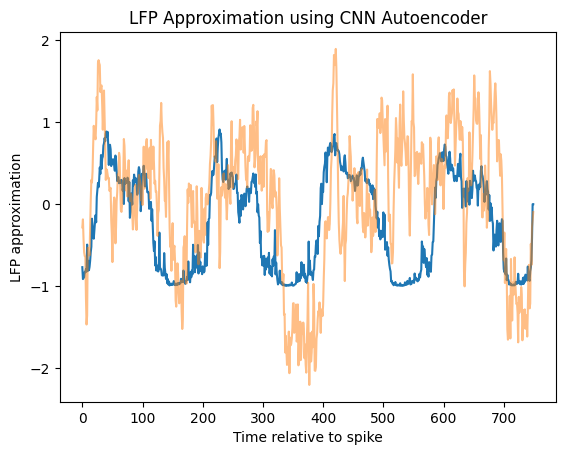

In [103]:
plt.plot(results[239,:])  # Plot the first result
plt.plot(X_train[2,0,:].cpu().numpy(), alpha=0.5)  # Plot the corresponding input for comparison
plt.ylabel("LFP approximation") 
plt.xlabel("Time relative to spike")
plt.title("LFP Approximation using CNN Autoencoder")
plt.show()

max val: 0.0024572741240262985, min val: -0.007013408932834864
Max neuron: 406, Min neuron: 216


Text(0, 0.5, 'Amplitude')

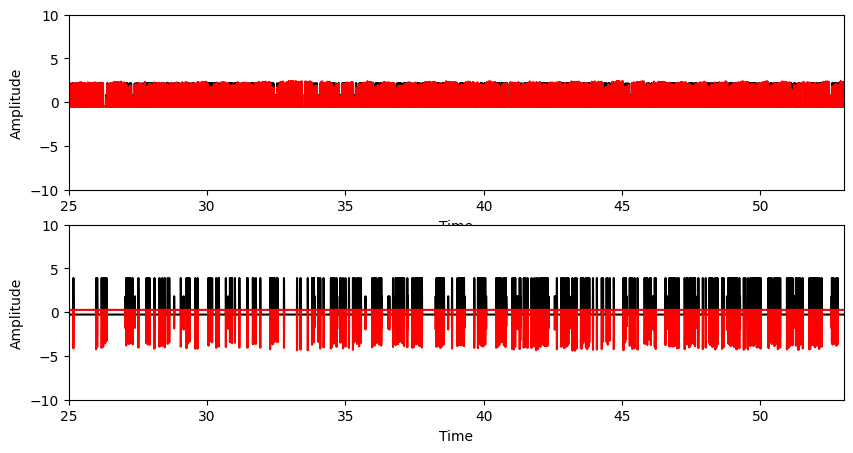

In [27]:
# find the neurons with the highest and lowest attribution scores 
max_neuron = np.argmax(np.mean(broadband_attr,axis=0)) # broadband channel 5
min_neuron = np.argmin(np.mean(broadband_attr,axis=0)) # broadband channel 5
max_val = np.max(np.mean(broadband_attr,axis=0))
min_val = np.min(np.mean(broadband_attr,axis=0))
print(f'max val: {max_val}, min val: {min_val}')    
print(f'Max neuron: {max_neuron}, Min neuron: {min_neuron}')

win = [0, 28]

# max_neuron = 191


fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)], 
           zscore(spikes_obj.spkMat[:int(attr_dur/bin_size),max_neuron]), 'k', label='firing rate')
ax[0].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)],
              zscore(broadband_attr[:,max_neuron]), 'r', label='attribution score')
ax[0].set_xlim([spikes_obj.timestamps[0]+win[0], spikes_obj.timestamps[0]+win[1]])
ax[0].set_ylim([-10, 10])
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Amplitude')

ax[1].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)], 
           zscore(spikes_obj.spkMat[:int(attr_dur/bin_size),min_neuron]), 'k', label='firing rate')
ax[1].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)],
              zscore(broadband_attr[:,min_neuron]), 'r', label='attribution score')
ax[1].set_xlim([spikes_obj.timestamps[0]+win[0], spikes_obj.timestamps[0]+win[1]])
ax[1].set_ylim([-10, 10])
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Amplitude')

# plt.imshow(attr_snippets[:,:,max_neuron], aspect='auto', cmap='bwr', extent=[-0.25, 0.5, 0, attr_snippets.shape[0]],vmin=-1, vmax=1)
# plt.colorbar()
# plt.tight_layout()
# plt.show()

100%|██████████| 623/623 [00:00<00:00, 1042.70it/s]


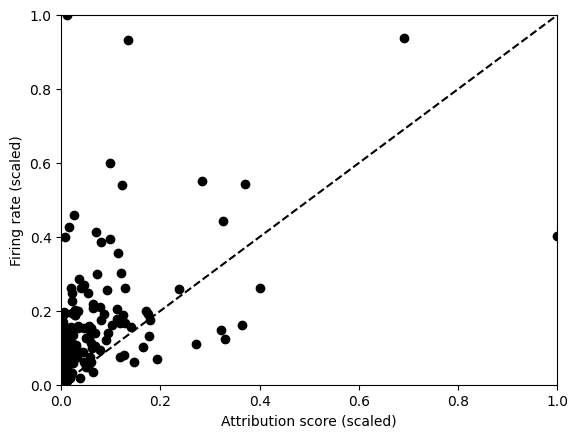

array([  0, 101, 191, 372, 440, 495], dtype=int64)

In [28]:
vis = session_obj.units['structure_acronym'].str.contains('VIS')
vis_idx = np.where(vis)[0]
fr  = session_obj.units[session_obj.units['structure_acronym'].str.contains('VIS')].firing_rate.values

tmp_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=1)
tmp_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[0] + attr_dur)

fr2 = np.mean(tmp_obj.spkMat[:, vis], axis=0) / attr_dur # firing rate in Hz
fr2[fr2 == 0] = 1e-10 # avoid log(0)

# import minmax scaling function
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

plt.plot(scaler.fit_transform(np.mean(np.abs(broadband_attr), axis=0)[vis].reshape(-1,1)) , scaler.fit_transform(fr2.reshape(-1,1)), 'ok')
plt.plot([-1,1], [-1, 1], '--k')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('Attribution score (scaled)')
plt.ylabel('Firing rate (scaled)')
plt.show()

# find neurons with high firing rate but low attribution scores
high_fr_low_attr = np.where((np.log(fr) > 2) & (np.mean(np.abs(broadband_attr), axis=0)[vis] < 0.00001))[0]
vis_idx[high_fr_low_attr]

In [ ]:
# correlation between attribution scores and linear model weights
weights = linear_model.model.coef_

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=weights, y=mean_attribution[5,0,:], ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(weights, mean_attribution[5,0,:])[0,1]:.2f}')
ax.set_xlim([-0.1, 0.1])
plt.show()

In [ ]:
# Import the new wavelet power function
import sys
sys.path.append('.')
from wavelet_power import wavelet_power

# Test the wavelet power analysis on LFP data
chani = 5  # channel to analyze
trial_data = lfp_obj.lfpMat[:1250, chani, 0].reshape(-1, 1)  # 1 second of data, single trial
timestamps = spikes_obj.timestamps[:1250]

# Run wavelet analysis
tf, tf_all, itpc, frex = wavelet_power(
    data=trial_data,
    timestamps=timestamps,
    fs=250,  # LFP sampling rate after downsampling
    freqs=[1, 100],
    num_frex=50,
    range_cycles=[4, 12],
    normalization='decibel',
    baseline=[timestamps[0], timestamps[0] + 0.5],  # first 500ms as baseline
    scaling='log',
    mkplt=1
)

print(f"Wavelet analysis complete:")
print(f"Time-frequency matrix shape: {tf.shape}")
print(f"Frequency range: {frex[0]:.2f} - {frex[-1]:.2f} Hz")
print(f"Max power: {np.max(tf):.2f} dB")

In [ ]:
# Multi-trial wavelet analysis example
# Create multiple "trials" by chunking the continuous LFP data
trial_length = 1000  # 4 seconds per trial at 250 Hz
n_trials = min(10, lfp_obj.lfpMat.shape[0] // trial_length)

# Reshape data into trials (time x trials)
multi_trial_data = np.zeros((trial_length, n_trials))
for trial in range(n_trials):
    start_idx = trial * trial_length
    end_idx = start_idx + trial_length
    multi_trial_data[:, trial] = lfp_obj.lfpMat[start_idx:end_idx, chani, 0]

trial_timestamps = np.arange(0, trial_length / 250, 1/250)

# Run wavelet analysis with multiple trials
tf_multi, tf_all_multi, itpc_multi, frex_multi = wavelet_power(
    data=multi_trial_data,
    timestamps=trial_timestamps,
    fs=250,
    freqs=[2, 80],
    num_frex=40,
    range_cycles=[3, 8],
    normalization='z-score',
    baseline=[0, 1],  # first 1 second as baseline
    scaling='log',
    mkplt=3  # plot both power and ITPC
)

print(f"Multi-trial analysis:")
print(f"Number of trials: {n_trials}")
print(f"ITPC range: {np.min(itpc_multi):.3f} - {np.max(itpc_multi):.3f}")
print(f"Power range: {np.min(tf_multi):.2f} - {np.max(tf_multi):.2f} z-score")